# Kaggle Regression & Classification

Notebook-ul principal pentru proiect: EDA, regresie pe `salary` si clasificare multi-clasa pe `vacation`.

Structura urmarita:
1. **EDA general**: incarcare date, tipuri de atribute, valori lipsa, distributii, outlieri, redundanta si analiza tintelor.
2. **Regresie**: baseline liniar, regularizare, feature engineering, pseudo-labeling, seed ensembling si submisia finala.
3. **Clasificare**: baseline cu arbore de decizie, modele de boosting/ensemble, evaluare per clasa si submisia finala.

Repo-ul este organizat pentru GitHub: datele sunt in `data/`, rezultatele in `results/`, graficele in `assets/figures/`, iar fisierele finale de upload sunt in `submissions/`.


In [1]:
# Daca mediul nu are dependintele instalate:
# %pip install numpy pandas scikit-learn matplotlib seaborn

import os
import warnings
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "CC_education_economy_train.csv").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd().resolve())
MPL_CACHE_DIR = REPO_ROOT / ".matplotlib_cache"
MPL_CACHE_DIR.mkdir(exist_ok=True)
XDG_CACHE_DIR = REPO_ROOT / ".cache"
XDG_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR.resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_DIR.resolve()))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd

RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", message="For backward compatibility, 'str' dtypes.*")
warnings.filterwarnings("ignore", message="Could not find the number of physical cores.*")



# PARTEA A - GENERAL

## A1. Incarcare date si rolul fiecarui fisier

Datele sunt pastrate in `data/`, iar notebook-ul detecteaza automat radacina repo-ului chiar daca este rulat din `notebooks/`.

- `data/CC_education_economy_train.csv` = antrenare;
- `data/CC_education_economy_test.csv` = validare locala;
- `data/CC_private_test.csv` = test privat pentru Kaggle/submission, fara tinte.


In [2]:
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "results"
REGRESSION_RESULTS_DIR = RESULTS_DIR / "regression"
CLASSIFICATION_RESULTS_DIR = RESULTS_DIR / "classification"
SUBMISSIONS_DIR = REPO_ROOT / "submissions"

for output_dir in [RESULTS_DIR, REGRESSION_RESULTS_DIR, CLASSIFICATION_RESULTS_DIR, SUBMISSIONS_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "CC_education_economy_train.csv"
TEST_PATH = DATA_DIR / "CC_education_economy_test.csv"
PRIVATE_TEST_PATH = DATA_DIR / "CC_private_test.csv"

REGRESSION_TARGET = "salary"
CLASSIFICATION_TARGET = "vacation"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
private_test_raw = pd.read_csv(PRIVATE_TEST_PATH) if PRIVATE_TEST_PATH.exists() else None

print("train:", train_raw.shape)
print("test local:", test_raw.shape)
if private_test_raw is not None:
    print("private test:", private_test_raw.shape)

display(train_raw.head())


train: (64000, 14)
test local: (16000, 14)
private test: (16000, 13)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,total_days_worked,aggregated_score,skill_bracket,vacation
0,Backend Developer,19,High School,12,Media,Large,USA,Yes,0,203997,4560,-0.723308,mid,Small
1,Backend Developer,4,High School,13,Telecom,Small,Germany,NaN,5,116239,960,-0.481551,high,No Vacation
2,Backend Developer,8,High School,16,Retail,Enterprise,Remote,No,4,145802,1920,-1.533057,high,No Vacation
3,Backend Developer,12,High School,9,Telecom,Enterprise,USA,Hybrid,2,190299,2880,0.527458,mid,Small
4,Backend Developer,14,High School,6,Telecom,Large,UK,Hybrid,4,152679,3360,-0.186280,low,No Vacation


## A2. Tipuri de atribute si valori lipsa

Aici este EDA general: Intelegem coloanele, tipurile si problemele evidente din date. Aceasta sectiune este utila si pentru regresie, si pentru clasificare.


In [3]:
FEATURE_COLS = [c for c in train_raw.columns if c not in [REGRESSION_TARGET, CLASSIFICATION_TARGET]]
NUMERIC_FEATURES_EDA = train_raw[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_FEATURES_EDA = [c for c in FEATURE_COLS if c not in NUMERIC_FEATURES_EDA]

feature_types = pd.DataFrame([
    ("job_title", "categorial nominal", "functie"),
    ("experience_years", "numeric", "experienta"),
    ("education_level", "ordinal/categorial", "nivel educational"),
    ("skills_count", "numeric discret", "numar skill-uri"),
    ("industry", "categorial nominal", "industrie"),
    ("company_size", "ordinal/categorial", "dimensiune companie"),
    ("location", "categorial nominal", "locatie"),
    ("remote_work", "categorial nominal", "are valori lipsa"),
    ("certifications", "numeric discret", "numar certificari"),
    ("total_days_worked", "numeric", "posibil redundant cu experience_years"),
    ("aggregated_score", "numeric continuu", "scor agregat"),
    ("skill_bracket", "ordinal/categorial", "nivel skill-uri"),
    ("salary", "tinta regresie", "nu este feature"),
    ("vacation", "tinta clasificare", "nu este feature"),
], columns=["coloana", "tip", "observatie"])

display(feature_types)

missing_report = pd.DataFrame({
    "missing_count": train_raw.isna().sum(),
    "missing_percent": (train_raw.isna().mean() * 100).round(2),
}).query("missing_count > 0").sort_values("missing_count", ascending=False)

print("Valori lipsa:")
display(missing_report)


,coloana,tip,observatie
0,job_title,categorial nominal,functie
1,experience_years,numeric,experienta
2,education_level,ordinal/categorial,nivel educational
3,skills_count,numeric discret,numar skill-uri
4,industry,categorial nominal,industrie
5,company_size,ordinal/categorial,dimensiune companie
6,location,categorial nominal,locatie
7,remote_work,categorial nominal,are valori lipsa
8,certifications,numeric discret,numar certificari
9,total_days_worked,numeric,posibil redundant cu experience_years


Valori lipsa:


,missing_count,missing_percent
remote_work,19153,29.93


## A3. Statistici si distributii generale pentru features

Statistici pentru numerice si un tabel pentru categorice/ordinale. Graficele de aici sunt generale: ne uitam la plaja valorilor si distributii.


In [4]:
# Statistici numerice: count, mean, std, min, percentile si max.
numeric_stats = train_raw[NUMERIC_FEATURES_EDA].describe().T.rename(columns={"50%": "median"})
numeric_stats = numeric_stats[["count", "mean", "std", "min", "25%", "median", "75%", "max"]]
display(numeric_stats.round(2))

# Tabel pentru categorice/ordinale: numar non-lipsa si numar valori unice.
cat_stats = pd.DataFrame({
    "non_missing_count": train_raw[CATEGORICAL_FEATURES_EDA].notna().sum(),
    "missing_count": train_raw[CATEGORICAL_FEATURES_EDA].isna().sum(),
    "unique_values_including_missing": train_raw[CATEGORICAL_FEATURES_EDA].nunique(dropna=False),
})
display(cat_stats)


,count,mean,std,min,25%,median,75%,max
experience_years,64000.0,9.97,6.05,0.0,5.00,10.0,15.00,20.00
skills_count,64000.0,11.60,10.74,1.0,5.00,10.0,15.00,69.00
certifications,64000.0,2.51,1.71,0.0,1.00,3.0,4.00,5.00
total_days_worked,64000.0,2393.51,1452.04,-1.0,1200.00,2400.0,3600.00,4800.00
aggregated_score,64000.0,0.00,1.00,-4.8,-0.67,0.0,0.68,4.22


,non_missing_count,missing_count,unique_values_including_missing
job_title,64000,0,12
education_level,64000,0,5
industry,64000,0,10
company_size,64000,0,5
location,64000,0,10
remote_work,44847,19153,4
skill_bracket,64000,0,3


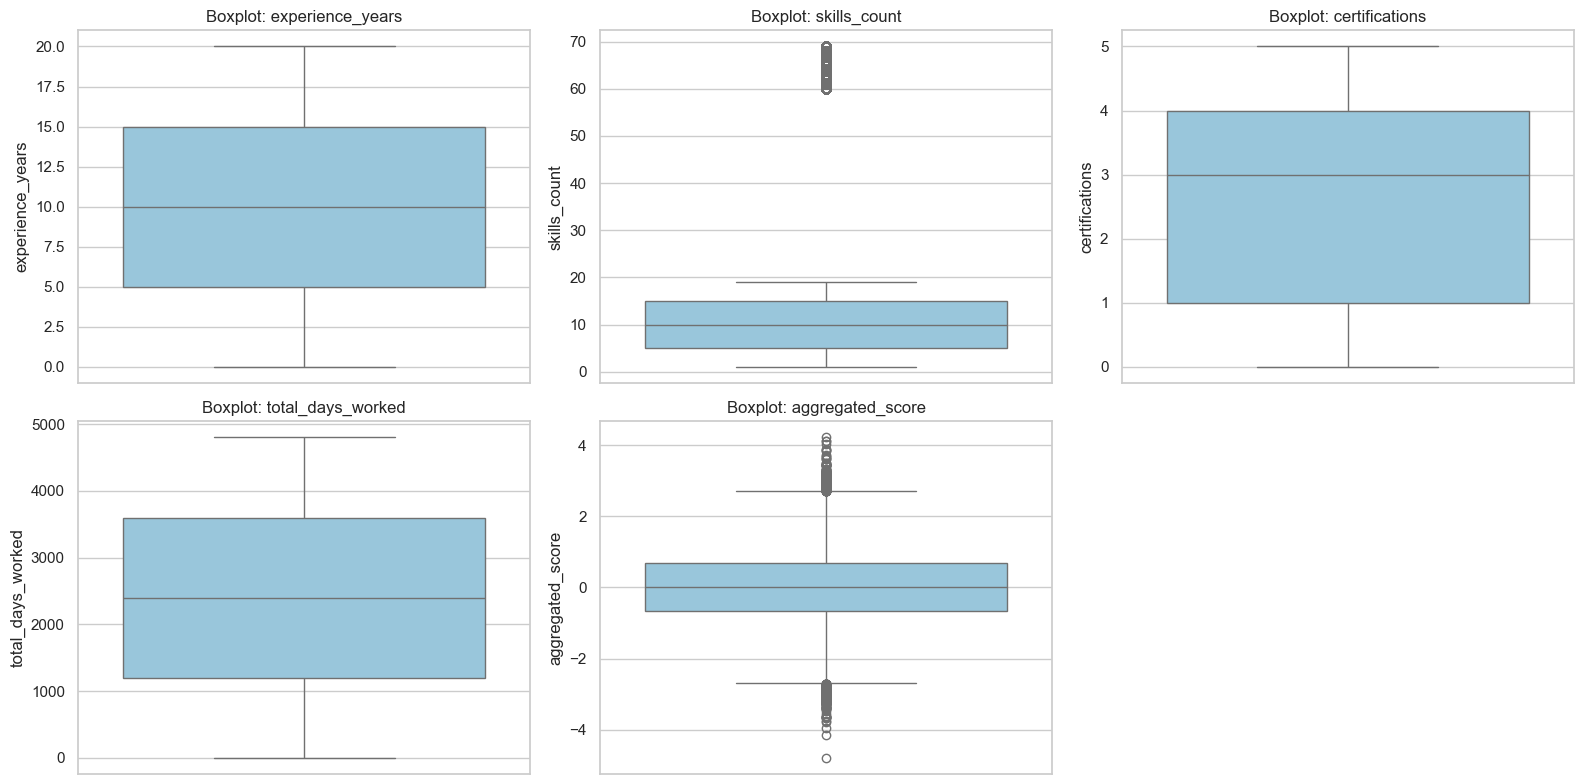

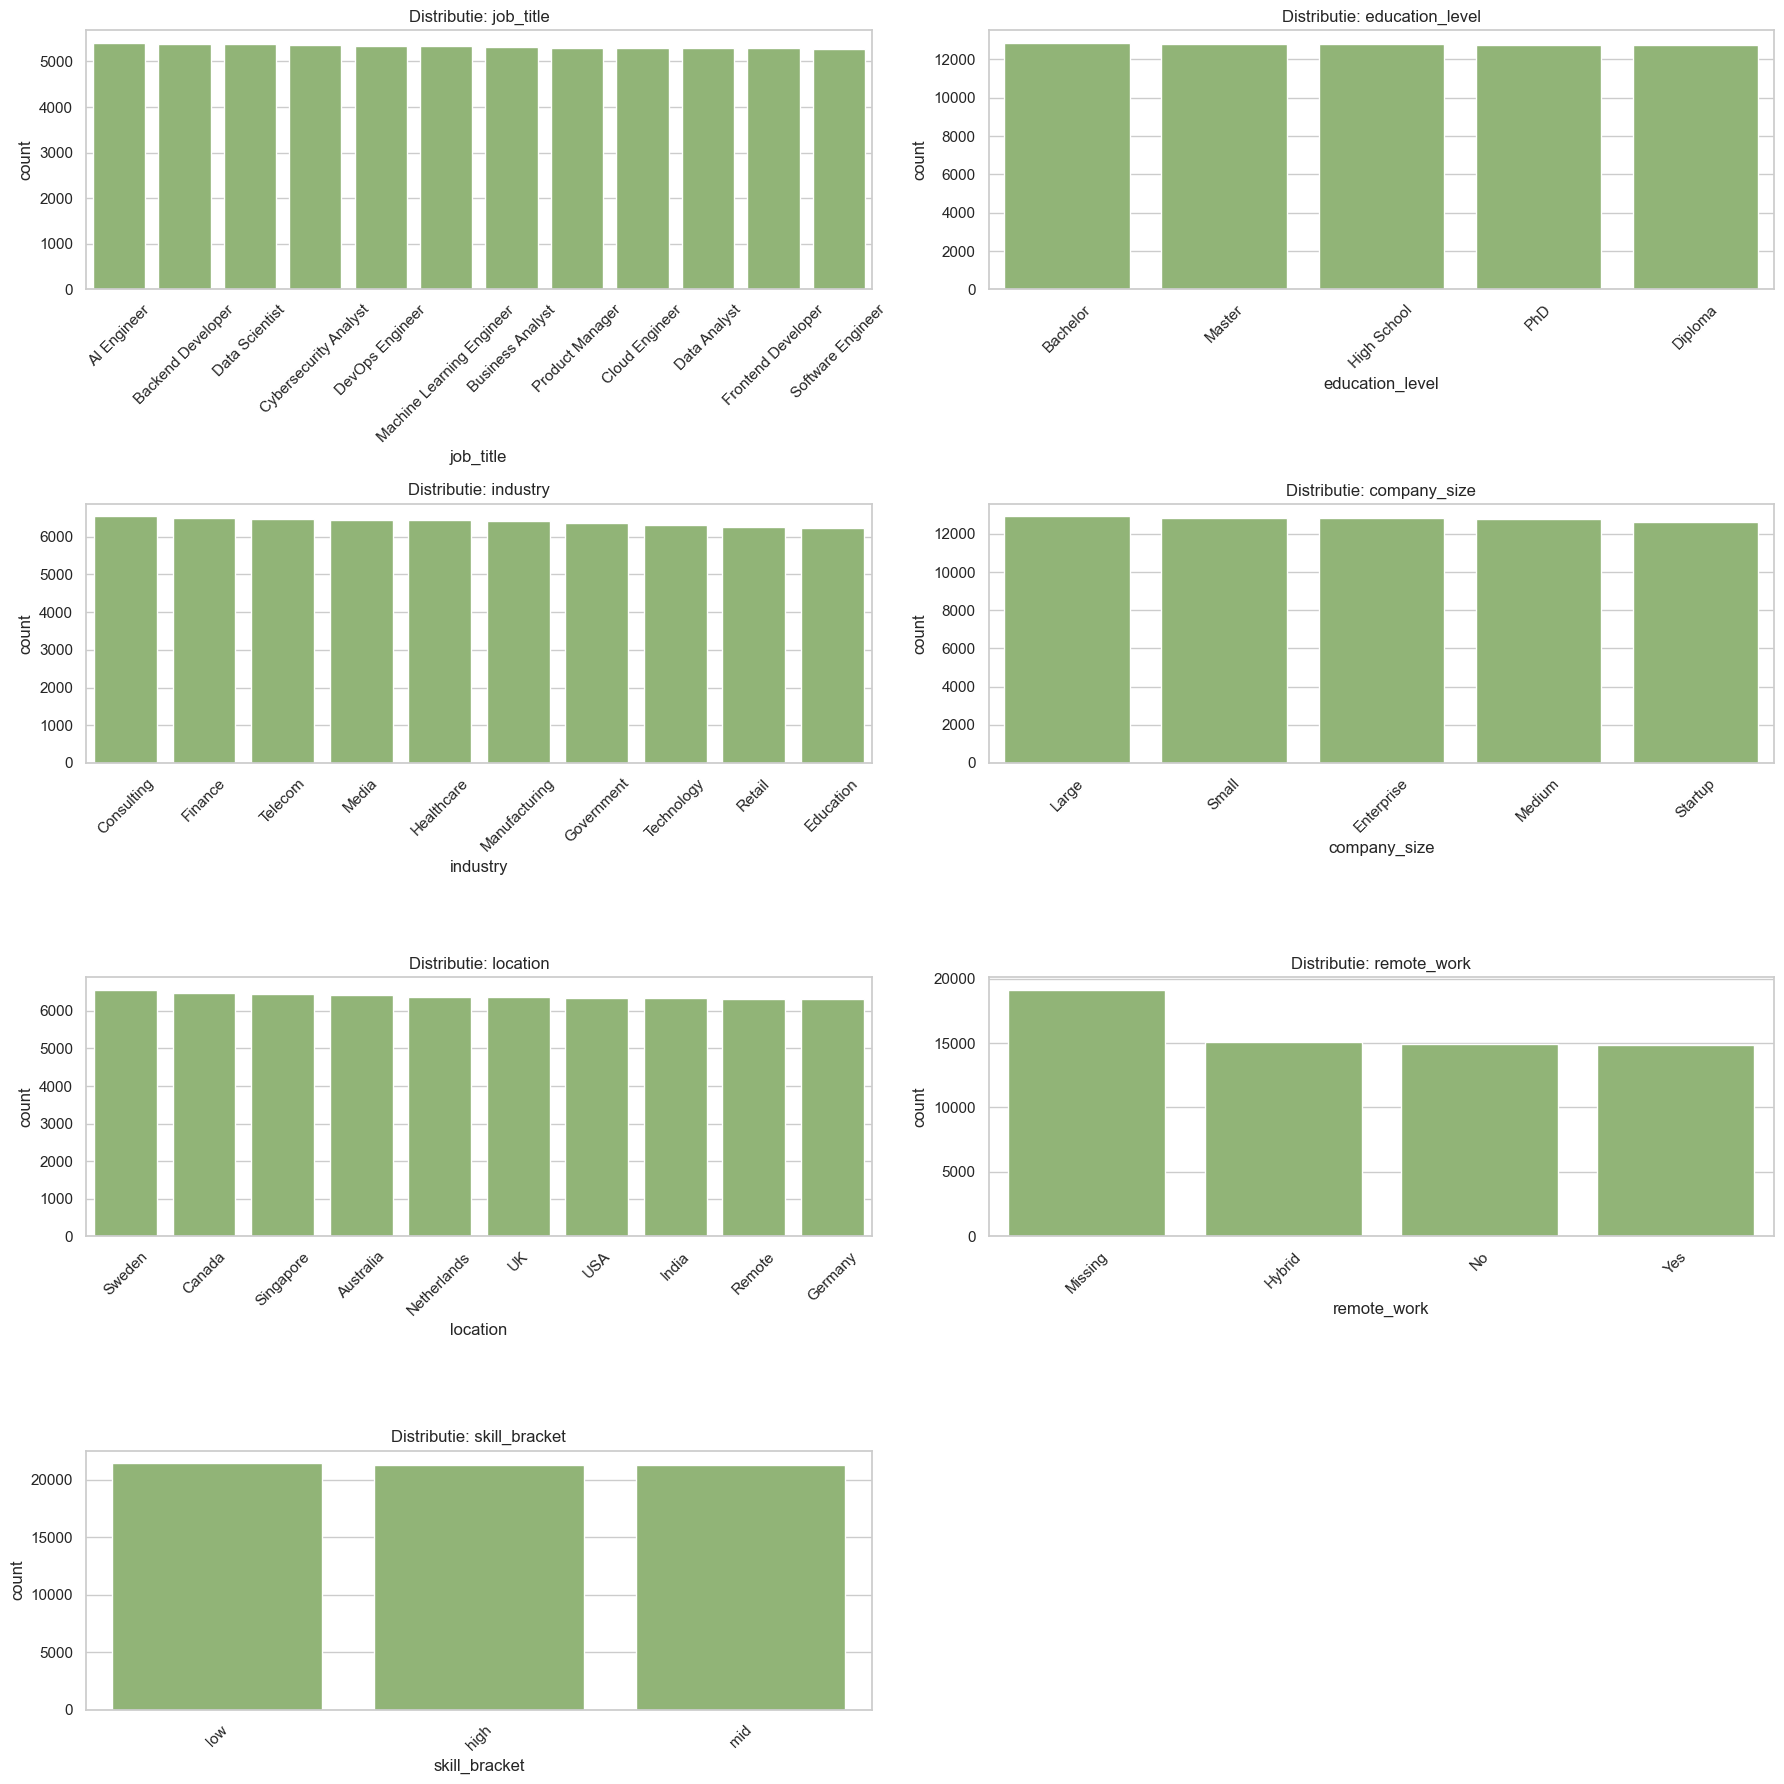

In [5]:
# Vizualizari generale: boxplot pentru numerice si countplot pentru categorice.
# Le grupam ca sa pastram EDA-ul compact si lizibil.
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOTS_AVAILABLE = True
except ImportError:
    PLOTS_AVAILABLE = False
    print("Pentru grafice ruleaza: %pip install matplotlib seaborn")

if PLOTS_AVAILABLE:
    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    numeric_axes = axes.ravel()
    for ax, col in zip(numeric_axes, NUMERIC_FEATURES_EDA):
        sns.boxplot(y=train_raw[col], ax=ax, color="#8ecae6")
        ax.set_title(f"Boxplot: {col}")
    for ax in numeric_axes[len(NUMERIC_FEATURES_EDA):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(4, 2, figsize=(18, 18))
    axes = axes.ravel()
    for ax, col in zip(axes, CATEGORICAL_FEATURES_EDA):
        values = train_raw[col].fillna("Missing").astype(str)
        sns.countplot(x=values, order=values.value_counts().index, ax=ax, color="#90be6d")
        ax.set_title(f"Distributie: {col}")
        ax.tick_params(axis="x", rotation=45)
    for ax in axes[len(CATEGORICAL_FEATURES_EDA):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## A4. Outlieri si redundanta intre features

Aceasta este tot parte generala: identificam valori extreme si features redundante inainte sa alegem modele. Tratamentul exact il aplicam mai jos, in partea de preprocesare.


,feature,iqr_lower,iqr_upper,outlier_count,outlier_percent
1,skills_count,-10.000000,30.000000,1909,2.98
4,aggregated_score,-2.701801,2.706318,437,0.68
0,experience_years,-10.000000,30.000000,0,0.00
2,certifications,-3.500000,8.500000,0,0.00
3,total_days_worked,-2400.000000,7200.000000,0,0.00


,experience_years,skills_count,certifications,total_days_worked,aggregated_score
experience_years,1.000,0.003,0.002,1.000,-0.001
skills_count,0.003,1.000,0.002,0.003,0.006
certifications,0.002,0.002,1.000,0.002,-0.000
total_days_worked,1.000,0.003,0.002,1.000,-0.001
aggregated_score,-0.001,0.006,-0.000,-0.001,1.000


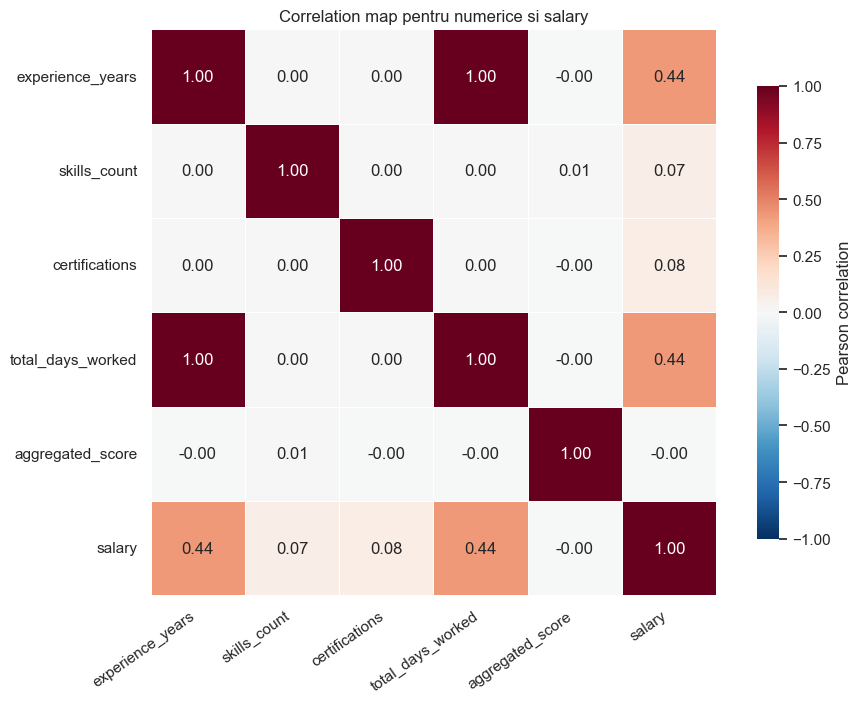

Perechi numerice foarte corelate:


,feature_1,feature_2,correlation
0,experience_years,total_days_worked,1.0


In [184]:
def iqr_bounds(series: pd.Series, q1=0.25, q3=0.75, multiplier=1.5):
    q_low = series.quantile(q1)
    q_high = series.quantile(q3)
    iqr = q_high - q_low
    return q_low - multiplier * iqr, q_high + multiplier * iqr

outlier_rows = []
for col in NUMERIC_FEATURES_EDA:
    lower, upper = iqr_bounds(train_raw[col])
    mask = (train_raw[col] < lower) | (train_raw[col] > upper)
    outlier_rows.append({
        "feature": col,
        "iqr_lower": lower,
        "iqr_upper": upper,
        "outlier_count": int(mask.sum()),
        "outlier_percent": round(mask.mean() * 100, 2),
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_report)

feature_corr = train_raw[NUMERIC_FEATURES_EDA].corr(numeric_only=True)
display(feature_corr.round(3))

# Pentru raport este mai util sa includem si targetul de regresie, altfel matricea pare aproape goala.
report_corr_cols = NUMERIC_FEATURES_EDA + [REGRESSION_TARGET]
report_corr = train_raw[report_corr_cols].corr(numeric_only=True)

if PLOTS_AVAILABLE:
    plt.figure(figsize=(9.5, 7.2))
    sns.heatmap(
        report_corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
    )
    plt.title("Correlation map pentru numerice si salary")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

high_corr_pairs = []
for i, c1 in enumerate(NUMERIC_FEATURES_EDA):
    for c2 in NUMERIC_FEATURES_EDA[i + 1:]:
        corr_value = feature_corr.loc[c1, c2]
        if abs(corr_value) >= 0.9:
            high_corr_pairs.append((c1, c2, corr_value))

print("Perechi numerice foarte corelate:")
display(pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"]).round(3))


### A4.1. Asociere intre atribute categoriale

Pentru cerinta de corelatie intre atribute categoriale folosesc Cramer's V, calculat din testul chi-square. Valori apropiate de 0 inseamna asociere slaba, valori apropiate de 1 inseamna asociere puternica. Scopul este sa vad daca exista perechi categoriale redundante, nu sa elimin automat coloane utile pentru tinte.


In [7]:
from itertools import combinations
from scipy.stats import chi2_contingency


def cramers_v(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    table = pd.crosstab(
        x.astype("object").where(x.notna(), "Missing").astype(str),
        y.astype("object").where(y.notna(), "Missing").astype(str),
    )
    chi2, p_value, _, _ = chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1
    value = 0.0 if min_dim <= 0 else np.sqrt((chi2 / n) / min_dim)
    return float(value), float(p_value)

# 1) Asociere intre feature-urile categoriale, ca sa vedem redundanta intre coloane.
categorical_association_rows = []
for col_a, col_b in combinations(CATEGORICAL_FEATURES_EDA, 2):
    value, p_value = cramers_v(train_raw[col_a], train_raw[col_b])
    categorical_association_rows.append({
        "feature_1": col_a,
        "feature_2": col_b,
        "cramers_v": value,
        "chi2_p_value": p_value,
    })

categorical_association_df = pd.DataFrame(categorical_association_rows).sort_values("cramers_v", ascending=False)
display(categorical_association_df.head(15).round(4))

strong_categorical_pairs = categorical_association_df.query("cramers_v >= 0.70")
print("Perechi categoriale cu asociere puternica (Cramer's V >= 0.70):")
display(strong_categorical_pairs.round(4))

# 2) Asociere intre fiecare categorica si tinta de clasificare vacation.
cramer_target_rows = []
for col in CATEGORICAL_FEATURES_EDA:
    value, p_value = cramers_v(train_raw[col], train_raw[CLASSIFICATION_TARGET])
    cramer_target_rows.append({
        "feature": col,
        "target": CLASSIFICATION_TARGET,
        "cramers_v": value,
        "chi2_p_value": p_value,
    })

cramer_target_df = pd.DataFrame(cramer_target_rows).sort_values("cramers_v", ascending=False)
print("Asociere Cramer's V intre categorice si tinta vacation:")
display(cramer_target_df.round(4))

# 3) Heatmap complet pentru categorice + target, util in raport.
cramer_cols = CATEGORICAL_FEATURES_EDA + [CLASSIFICATION_TARGET]
cramer_matrix = pd.DataFrame(np.eye(len(cramer_cols)), index=cramer_cols, columns=cramer_cols)
for col_a, col_b in combinations(cramer_cols, 2):
    value, _ = cramers_v(train_raw[col_a], train_raw[col_b])
    cramer_matrix.loc[col_a, col_b] = value
    cramer_matrix.loc[col_b, col_a] = value

display(cramer_matrix.round(3))

if PLOTS_AVAILABLE:
    plt.figure(figsize=(9.5, 7.5))
    sns.heatmap(
        cramer_matrix,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Cramer's V"},
    )
    plt.title("Cramer's V map pentru categorice si vacation")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


,feature_1,feature_2,cramers_v,chi2_p_value
2,job_title,company_size,0.0144,0.1566
1,job_title,industry,0.0144,0.0767
18,location,remote_work,0.0136,0.1303
5,job_title,skill_bracket,0.0133,0.4177
4,job_title,remote_work,0.0132,0.4374
3,job_title,location,0.0131,0.4865
12,industry,location,0.0129,0.1182
15,company_size,location,0.0126,0.2671
13,industry,remote_work,0.0121,0.4039
14,industry,skill_bracket,0.0120,0.4258


Perechi categoriale cu asociere puternica (Cramer's V >= 0.70):


,feature_1,feature_2,cramers_v,chi2_p_value


Concluzia folosita mai departe: nu elimin automat categorice doar pentru ca sunt asociate intre ele. Eliminarea se face doar cand exista risc clar de redundanta/leakage sau cand atributul nu exista in private test. Pentru regresie, exemplul clar este `total_days_worked`, aproape redundant cu experienta si eliminat in B2.


## A5. Privire scurta asupra tintelor

Aici doar intelegem cele doua tinte ale temei:
- `vacation` este tinta de clasificare si necesita analiza echilibrului de clase;
- `salary` este tinta de regresie si necesita analiza distributiei valorilor.

Aceasta este doar o privire generala; modelele propriu-zise sunt antrenate separat in Partea B pentru regresie si in Partea C pentru clasificare.


,count,percent
vacation,,
No Vacation,34686,54.20
Small,12877,20.12
Medium,8527,13.32
Large,7910,12.36


,salary
count,64000.00
mean,145683.57
std,37384.76
min,31867.00
25%,119209.75
50%,143299.00
75%,169582.25
max,333046.00


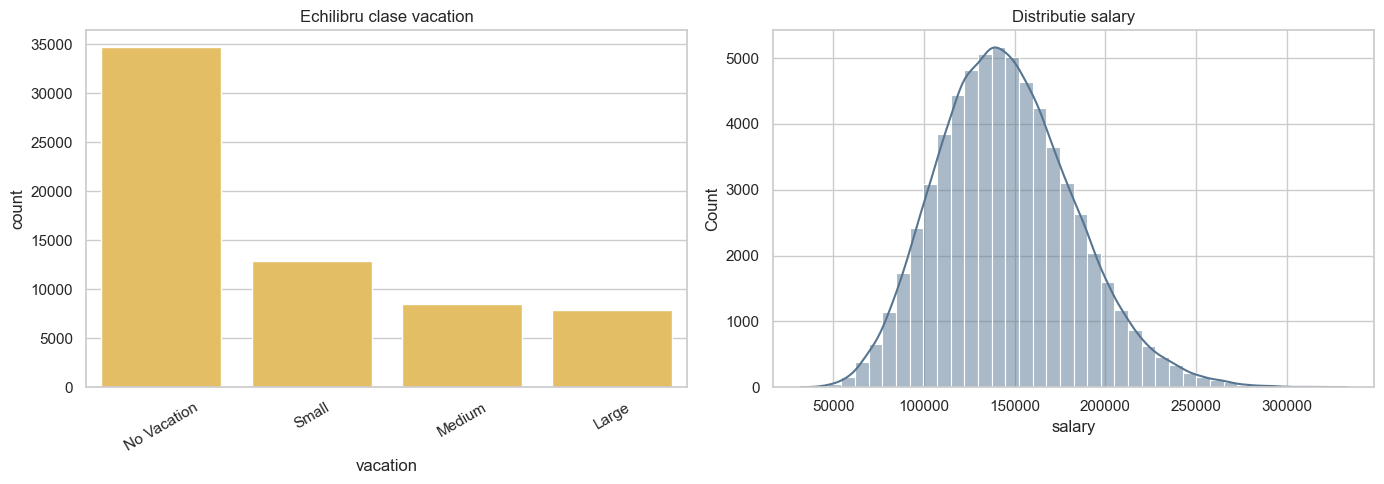

In [8]:
class_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent"),
], axis=1)
display(class_balance)

display(train_raw[REGRESSION_TARGET].describe().to_frame("salary").round(2))

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.countplot(x=train_raw[CLASSIFICATION_TARGET], order=train_raw[CLASSIFICATION_TARGET].value_counts().index, ax=axes[0], color="#f9c74f")
    axes[0].set_title("Echilibru clase vacation")
    axes[0].tick_params(axis="x", rotation=30)

    sns.histplot(train_raw[REGRESSION_TARGET], bins=40, kde=True, ax=axes[1], color="#577590")
    axes[1].set_title("Distributie salary")
    plt.tight_layout()
    plt.show()


# PARTEA B - REGRESIE

De aici incepe lucrul strict pentru regresie. Tinta este `salary`.


## B1. EDA specific pentru regresie

Pentru regresie urmaresc legatura dintre `salary` si restul atributelor:

- corelatii numerice cu `salary`;
- diferente de salariu pe categorii;
- cateva scatter/box plots relevante, pastrate intr-un numar mic ca sa ramana usor de citit.


In [9]:
NUMERIC_COLS_WITH_TARGET = NUMERIC_FEATURES_EDA + [REGRESSION_TARGET]
regression_corr = train_raw[NUMERIC_COLS_WITH_TARGET].corr(numeric_only=True)

print("Corelatie numerice cu salary:")
display(regression_corr[REGRESSION_TARGET].sort_values(ascending=False).round(3))

for col in ["job_title", "education_level", "company_size", "location", "remote_work", "skill_bracket"]:
    grouped = train_raw.groupby(col, dropna=False)[REGRESSION_TARGET].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False).round(2)
    print(f"\nSalary by {col}")
    display(grouped)


Corelatie numerice cu salary:


salary               1.000
experience_years     0.437
total_days_worked    0.437
certifications       0.077
skills_count         0.065
aggregated_score    -0.004
Name: salary, dtype: float64


Salary by job_title


,count,mean,median,std
job_title,,,,
AI Engineer,5410,173162.56,171337.5,38102.99
Machine Learning Engineer,5337,163118.60,160990.0,36874.80
Product Manager,5302,157107.45,155277.5,35567.85
Cloud Engineer,5300,152619.18,150332.0,35386.68
DevOps Engineer,5344,150013.86,148571.0,34529.76
Cybersecurity Analyst,5356,147907.72,145822.5,34245.70
Data Scientist,5383,147289.90,145268.0,34156.61
Software Engineer,5272,141563.93,138737.5,33902.85
Backend Developer,5389,139574.41,137083.0,33080.63



Salary by education_level


...

,count,mean,median,std
location,,,,
USA,6352,181341.00,178628.0,37782.33
Canada,6469,167938.89,166020.0,35087.79
UK,6365,160347.37,158671.0,33426.84
Germany,6325,153640.37,151718.0,31782.86
Remote,6328,139429.03,137542.5,28919.00
Sweden,6570,139359.67,138062.0,28993.86
Singapore,6438,139058.85,137503.0,29014.11
Netherlands,6376,138904.57,136798.5,29313.18
Australia,6434,138865.53,137025.5,29264.78



Salary by remote_work


,count,mean,median,std
remote_work,,,,
Yes,14838,149609.81,147698.5,37476.23
NaN,19153,145131.00,142754.0,37411.27
Hybrid,15054,144482.91,141962.0,37218.57
No,14955,143704.32,141238.0,37148.23



Salary by skill_bracket


,count,mean,median,std
skill_bracket,,,,
high,21277,151338.83,149227.0,37797.32
mid,21253,145485.08,142931.0,37225.30
low,21470,140275.62,137846.0,36301.60


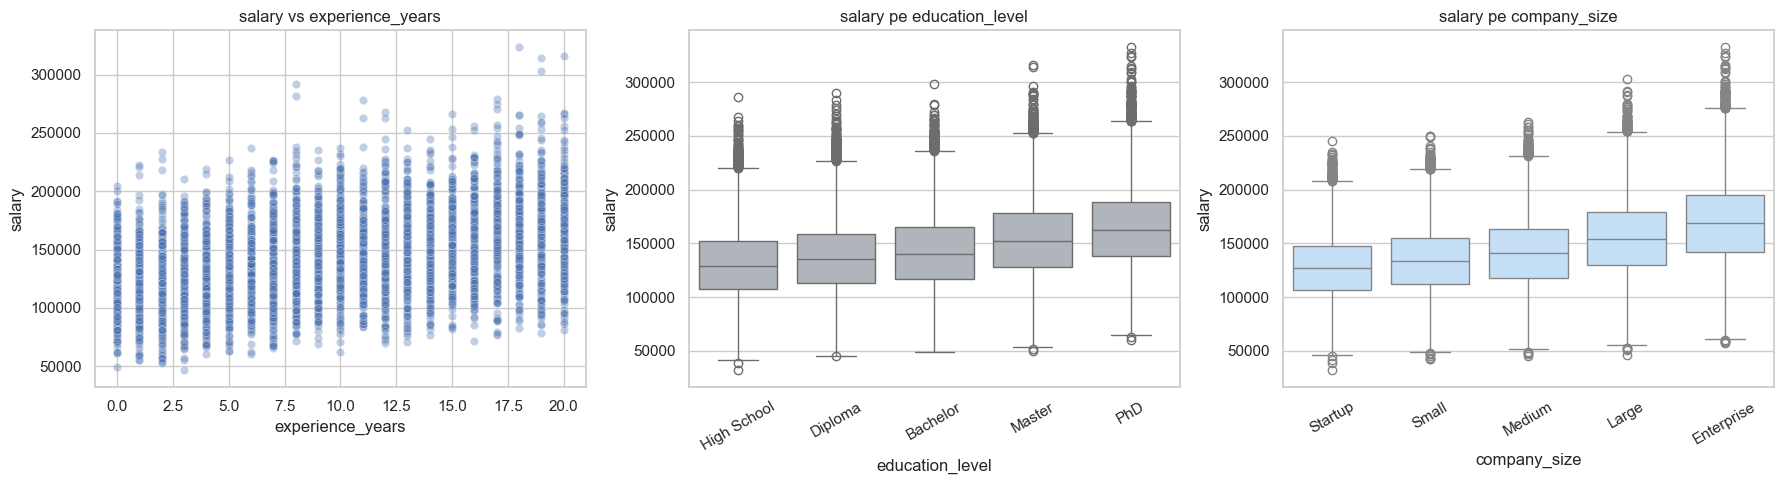

In [10]:
if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(data=train_raw.sample(min(5000, len(train_raw)), random_state=RANDOM_STATE), x="experience_years", y=REGRESSION_TARGET, alpha=0.35, ax=axes[0])
    axes[0].set_title("salary vs experience_years")

    sns.boxplot(data=train_raw, x="education_level", y=REGRESSION_TARGET, order=["High School", "Diploma", "Bachelor", "Master", "PhD"], ax=axes[1], color="#adb5bd")
    axes[1].set_title("salary pe education_level")
    axes[1].tick_params(axis="x", rotation=30)

    sns.boxplot(data=train_raw, x="company_size", y=REGRESSION_TARGET, order=["Startup", "Small", "Medium", "Large", "Enterprise"], ax=axes[2], color="#bde0fe")
    axes[2].set_title("salary pe company_size")
    axes[2].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()


## B2. Preprocesare pentru regresie

Preprocesarea de aici este pentru modelele locale simple folosite ca baseline:

- elimin `salary`, pentru ca este tinta;
- elimin `vacation`, pentru ca apartine taskului de clasificare si ar produce leakage;
- elimin `total_days_worked`, fiind aproape identic cu `experience_years`;
- tratez outlierii din `aggregated_score` prin IQR clipping, cu limite calculate doar pe train;
- adaug cateva features simple derivate;
- folosesc imputare, OneHotEncoding si StandardScaler in pipeline-ul modelelor liniare.

Modelele grele din perfectionarea Kaggle folosesc o reteta separata, documentata in B4: target encoding, pseudo-labeling, seed ensembling si binning data-centric.


In [11]:
# Coloane excluse din regresie.
EXCLUDED_FROM_REGRESSION = [REGRESSION_TARGET, CLASSIFICATION_TARGET, "total_days_worked"]
BASE_FEATURES = [c for c in train_raw.columns if c not in EXCLUDED_FROM_REGRESSION]

print("Features folosite in regresie:")
print(BASE_FEATURES)
print("Features excluse:")
print(EXCLUDED_FROM_REGRESSION)

AGG_SCORE_LOWER, AGG_SCORE_UPPER = iqr_bounds(train_raw["aggregated_score"])
outlier_mask = (train_raw["aggregated_score"] < AGG_SCORE_LOWER) | (train_raw["aggregated_score"] > AGG_SCORE_UPPER)
print("aggregated_score IQR bounds:", AGG_SCORE_LOWER, AGG_SCORE_UPPER)
print("Numar outlieri aggregated_score in train:", int(outlier_mask.sum()))


Features folosite in regresie:
['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'aggregated_score', 'skill_bracket']
Features excluse:
['salary', 'vacation', 'total_days_worked']
aggregated_score IQR bounds: -2.7018013625585664 2.7063182160590395
Numar outlieri aggregated_score in train: 437


In [12]:
EDUCATION_ORDER = {"High School": 0, "Diploma": 1, "Bachelor": 2, "Master": 3, "PhD": 4}
COMPANY_SIZE_ORDER = {"Startup": 0, "Small": 1, "Medium": 2, "Large": 3, "Enterprise": 4}
SKILL_BRACKET_ORDER = {"low": 0, "mid": 1, "high": 2}

ORDINAL_DERIVED_COLS = ["education_level_ord", "company_size_ord", "skill_bracket_ord"]


def add_regression_base_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Tratam outlierii din aggregated_score prin clipping cu limite calculate pe train.
    # Pastram semnul original al scorului; nu mai adaugam abs/sq, ca sa nu pierdem directia negativ/pozitiv.
    if "aggregated_score" in out.columns:
        out["aggregated_score"] = out["aggregated_score"].clip(AGG_SCORE_LOWER, AGG_SCORE_UPPER)

    # Lipsa din remote_work poate fi informatie, deci pastram indicator separat.
    # Missing-ul din remote_work este deja imputat ca "Missing" in pipeline.
    # Indicatorul separat testeaza doar daca lipsa in sine are semnal predictiv.
    if "remote_work" in out.columns:
        out["remote_work_missing"] = out["remote_work"].isna().astype("int8")

    # Codari ordinale suplimentare; pastram si textul original pentru OneHotEncoding.
    if "education_level" in out.columns:
        out["education_level_ord"] = out["education_level"].map(EDUCATION_ORDER).astype(float)
    if "company_size" in out.columns:
        out["company_size_ord"] = out["company_size"].map(COMPANY_SIZE_ORDER).astype(float)
    if "skill_bracket" in out.columns:
        out["skill_bracket_ord"] = out["skill_bracket"].map(SKILL_BRACKET_ORDER).astype(float)

    # Interactiuni simple pentru experienta + competente.
    if {"experience_years", "skills_count"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["skills_per_year"] = (out["skills_count"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["skills_count"])
        out["experience_x_skills"] = out["experience_years"] * out["skills_count"]

    if {"experience_years", "certifications"}.issubset(out.columns):
        years = out["experience_years"].replace(0, np.nan)
        out["certifications_per_year"] = (out["certifications"] / years).replace([np.inf, -np.inf], np.nan).fillna(out["certifications"])

    return out


X_train_base = add_regression_base_features(train_raw[BASE_FEATURES])
y_train = train_raw[REGRESSION_TARGET]
X_test_base = add_regression_base_features(test_raw[BASE_FEATURES])
y_test = test_raw[REGRESSION_TARGET]

CAT_COLS = X_train_base.select_dtypes(include=["object", "category"]).columns.tolist()
NUM_COLS = [c for c in X_train_base.columns if c not in CAT_COLS]

# Modelele liniare folosesc OneHot pe coloanele ordinale originale, deci excludem variantele _ord ca sa evitam dublarea.
LINEAR_NUM_COLS = [c for c in NUM_COLS if c not in ORDINAL_DERIVED_COLS]
LINEAR_CAT_COLS = CAT_COLS

print("X_train:", X_train_base.shape, "X_test:", X_test_base.shape)
print("Linear numerice:", LINEAR_NUM_COLS)
print("Linear categorice:", LINEAR_CAT_COLS)


X_train: (64000, 18) X_test: (16000, 18)
Linear numerice: ['experience_years', 'skills_count', 'certifications', 'aggregated_score', 'remote_work_missing', 'skills_per_year', 'experience_x_skills', 'certifications_per_year']
Linear categorice: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']


# B3. Modele de regresie locale si metrici


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_linear_preprocessor():
    """Pentru modele liniare: imputare + OneHot + StandardScaler."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, LINEAR_NUM_COLS),
        ("cat", categorical_pipeline, LINEAR_CAT_COLS),
    ])


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(name, model, preprocessing_note, hyperparams_note):
    model.fit(X_train_base, y_train)
    train_pred = model.predict(X_train_base)
    test_pred = model.predict(X_test_base)

    train_metrics = regression_metrics(y_train, train_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    row = {
        "model": name,
        "preprocessing": preprocessing_note,
        "hyperparams": hyperparams_note,
        "train_MSE": train_metrics["MSE"],
        "test_MSE": test_metrics["MSE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_R2": test_metrics["R2"],
    }
    return row, test_pred, model




## B3. Baseline regresie si metrici

Primul reper pentru regresie este `LinearRegression`. Dupa el testez regularizarea cu `Ridge` si `Lasso`, apoi compar modelele prin:

- `MSE`, metrica principala pentru regresie in acest proiect;
- `RMSE` si `MAE`, pentru interpretare in unitati apropiate de salariu;
- `R2`, ca masura a variatiei explicate.


In [14]:
# Baseline de regresie: LinearRegression.
linear_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", LinearRegression()),
])

linear_metrics, linear_pred, fitted_linear_model = evaluate_model(
    name="LinearRegression_baseline",
    model=linear_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="fara regularizare",
)

display(pd.DataFrame([linear_metrics]))


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231


## B3.1. Ridge - regularizare L2

Dupa baseline-ul liniar simplu, adaug regularizare L2 prin `Ridge`. Testez doua valori pentru `alpha`, deoarece acest hiperparametru controleaza cat de puternic sunt penalizati coeficientii. Scopul este sa vedem daca regularizarea reduce overfitting-ul fata de `LinearRegression`.


In [15]:

# Varianta cu regularizare Ridge: testam doua valori diferite pentru alpha.
# Am ales 1.0 si 10.0 ca valori comune de testat pentru Ridge.
ridge_1_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=1.0)),
])
ridge_10_model = Pipeline([
    ("preprocess", make_linear_preprocessor()),
    ("model", Ridge(alpha=10.0)),
])

ridge_1_metrics, ridge_1_pred, fitted_ridge_1_model = evaluate_model(
    name="Ridge_alpha_1",
    model=ridge_1_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=1.0",
)
ridge_10_metrics, ridge_10_pred, fitted_ridge_10_model = evaluate_model(
    name="Ridge_alpha_10",
    model=ridge_10_model,
    preprocessing_note="imputare + OneHot + StandardScaler",
    hyperparams_note="alpha=10.0",
)

all_results = [linear_metrics, ridge_1_metrics, ridge_10_metrics]
all_predictions = {
    "LinearRegression_baseline": linear_pred,
    "Ridge_alpha_1": ridge_1_pred,
    "Ridge_alpha_10": ridge_10_pred,
}
all_fitted_models = {
    "LinearRegression_baseline": fitted_linear_model,
    "Ridge_alpha_1": fitted_ridge_1_model,
    "Ridge_alpha_10": fitted_ridge_10_model,
}

metrics_df = pd.DataFrame(all_results).sort_values("test_MSE")
display(metrics_df)


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
1,Ridge_alpha_1,imputare + OneHot + StandardScaler,alpha=1.0,5.560510e+07,5.493713e+07,7411.958401,5731.141391,0.960230
2,Ridge_alpha_10,imputare + OneHot + StandardScaler,alpha=10.0,5.560724e+07,5.494210e+07,7412.293624,5731.146498,0.960227


### B3.2. Lasso - regularizare L1 si selectie de features

`Lasso` este tot regresie liniara, dar cu penalizare L1. Diferenta fata de Ridge este ca Lasso poate impinge unii coeficienti exact la `0`.

In aceasta celula testez doar variantele Lasso pentru mai multe valori de `alpha`. Comparatia completa cu baseline-ul, Ridge si modelul combinat ElasticNet este separata in B3.3.

`random_state=RANDOM_STATE` fixeaza aleatorul intern al modelului, astfel incat rezultatele sa fie reproductibile. Cu aceeasi valoare, rerularea notebook-ului produce aceleasi impartiri/initializari acolo unde algoritmul foloseste pasi aleatori.


In [16]:
lasso_experiments = []
lasso_predictions = {}
lasso_fitted_models = {}

for alpha in [0.1, 1.0, 10.0]:
    lasso_model = Pipeline([
        ("preprocess", make_linear_preprocessor()),
        ("model", Lasso(alpha=alpha, max_iter=5000, random_state=RANDOM_STATE)),
    ])
    lasso_metrics, lasso_pred, fitted_lasso_model = evaluate_model(
        name=f"Lasso_alpha_{alpha}",
        model=lasso_model,
        preprocessing_note="imputare + OneHot + StandardScaler",
        hyperparams_note=f"alpha={alpha}, penalty=L1",
    )
    lasso_experiments.append(lasso_metrics)
    lasso_predictions[lasso_metrics["model"]] = lasso_pred
    lasso_fitted_models[lasso_metrics["model"]] = fitted_lasso_model

lasso_df = pd.DataFrame(lasso_experiments).sort_values("test_MSE")
display(lasso_df)



,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
1,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
0,Lasso_alpha_0.1,imputare + OneHot + StandardScaler,"alpha=0.1, penalty=L1",5.560506e+07,5.493615e+07,7411.892606,5731.105255,0.960231
2,Lasso_alpha_10.0,imputare + OneHot + StandardScaler,"alpha=10.0, penalty=L1",5.563711e+07,5.496589e+07,7413.898515,5732.703721,0.960210


### B3.3. ElasticNet - Lasso si Ridge in acelasi model

`ElasticNet` combina cele doua tipuri de regularizare: L1, ca la Lasso, si L2, ca la Ridge. Parametrul `alpha` controleaza forta totala a penalizarii, iar `l1_ratio` controleaza proportia dintre Lasso si Ridge.

Nu folosesc GridSearch aici, ci doar trei incercari simple. Scopul este sa verific daca o penalizare combinata ajuta fata de Ridge si Lasso rulate separat. Daca ElasticNet iese mai slab, explicatia probabila este ca penalizarea L1+L2 devine prea restrictiva pentru setul de feature-uri OneHot si impinge modelul spre underfitting.


In [17]:
from sklearn.linear_model import ElasticNet

elasticnet_experiments = []
elasticnet_predictions = {}
elasticnet_fitted_models = {}

# Trei variante simple, nu GridSearch:
# - l1_ratio=0.25: mai aproape de Ridge
# - l1_ratio=0.50: balans L1/L2
# - l1_ratio=0.75: mai aproape de Lasso
elasticnet_configs = [
    {"alpha": 0.01, "l1_ratio": 0.25},
    {"alpha": 0.01, "l1_ratio": 0.50},
    {"alpha": 0.01, "l1_ratio": 0.75},
]

for config in elasticnet_configs:
    alpha = config["alpha"]
    l1_ratio = config["l1_ratio"]
    elasticnet_model = Pipeline([
        ("preprocess", make_linear_preprocessor()),
        ("model", ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ])

    elasticnet_metrics, elasticnet_pred, fitted_elasticnet_model = evaluate_model(
        name=f"ElasticNet_alpha_{alpha}_l1ratio_{l1_ratio}",
        model=elasticnet_model,
        preprocessing_note="imputare + OneHot + StandardScaler",
        hyperparams_note=f"alpha={alpha}, l1_ratio={l1_ratio}, penalty=L1+L2",
    )
    elasticnet_experiments.append(elasticnet_metrics)
    elasticnet_predictions[elasticnet_metrics["model"]] = elasticnet_pred
    elasticnet_fitted_models[elasticnet_metrics["model"]] = fitted_elasticnet_model

all_results = [
    linear_metrics,
    ridge_1_metrics,
    ridge_10_metrics,
    *lasso_experiments,
    *elasticnet_experiments,
]

all_predictions = {
    "LinearRegression_baseline": linear_pred,
    "Ridge_alpha_1": ridge_1_pred,
    "Ridge_alpha_10": ridge_10_pred,
    **lasso_predictions,
    **elasticnet_predictions,
}

all_fitted_models = {
    "LinearRegression_baseline": fitted_linear_model,
    "Ridge_alpha_1": fitted_ridge_1_model,
    "Ridge_alpha_10": fitted_ridge_10_model,
    **lasso_fitted_models,
    **elasticnet_fitted_models,
}

metrics_df = pd.DataFrame(all_results).sort_values("test_MSE")
metrics_df["train_RMSE"] = np.sqrt(metrics_df["train_MSE"])

train_mae_by_model = {}
for model_name, fitted_model in all_fitted_models.items():
    train_pred_for_comparison = fitted_model.predict(X_train_base)
    train_mae_by_model[model_name] = mean_absolute_error(y_train, train_pred_for_comparison)

metrics_df["train_MAE"] = metrics_df["model"].map(train_mae_by_model)

comparison_columns = [
    "model",
    "preprocessing",
    "hyperparams",
    "test_MSE",
    "test_RMSE",
    "test_MAE",
    "train_MSE",
    "train_RMSE",
    "train_MAE",
]

linear_regularization_comparison = metrics_df[comparison_columns].sort_values(
    by=["test_MSE", "test_RMSE", "test_MAE", "train_MSE", "train_RMSE", "train_MAE"],
    ascending=False,
)

print("Variante ElasticNet - Lasso + Ridge in acelasi estimator:")
display(pd.DataFrame(elasticnet_experiments).sort_values("test_MSE"))

print("Comparatie completa modele liniare si regularizate:")
display(linear_regularization_comparison)



Variante ElasticNet - Lasso + Ridge in acelasi estimator:


,model,preprocessing,hyperparams,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
2,ElasticNet_alpha_0.01_l1ratio_0.75,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.75, penalty=L1+L2",5.613223e+07,5.551172e+07,7450.618769,5752.568988,0.959814
1,ElasticNet_alpha_0.01_l1ratio_0.5,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.5, penalty=L1+L2",5.761221e+07,5.703513e+07,7552.160354,5816.396708,0.958712
0,ElasticNet_alpha_0.01_l1ratio_0.25,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.25, penalty=L1+L2",5.990999e+07,5.937184e+07,7705.312333,5917.595079,0.957020


Comparatie completa modele liniare si regularizate:


,model,preprocessing,hyperparams,test_MSE,test_RMSE,test_MAE,train_MSE,train_RMSE,train_MAE
6,ElasticNet_alpha_0.01_l1ratio_0.25,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.25, penalty=L1+L2",5.937184e+07,7705.312333,5917.595079,5.990999e+07,7740.154380,5904.184992
7,ElasticNet_alpha_0.01_l1ratio_0.5,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.5, penalty=L1+L2",5.703513e+07,7552.160354,5816.396708,5.761221e+07,7590.270426,5807.827318
8,ElasticNet_alpha_0.01_l1ratio_0.75,imputare + OneHot + StandardScaler,"alpha=0.01, l1_ratio=0.75, penalty=L1+L2",5.551172e+07,7450.618769,5752.568988,5.613223e+07,7492.144337,5747.608380
5,Lasso_alpha_10.0,imputare + OneHot + StandardScaler,"alpha=10.0, penalty=L1",5.496589e+07,7413.898515,5732.703721,5.563711e+07,7459.028659,5730.054065
2,Ridge_alpha_10,imputare + OneHot + StandardScaler,alpha=10.0,5.494210e+07,7412.293624,5731.146498,5.560724e+07,7457.026044,5729.741207
1,Ridge_alpha_1,imputare + OneHot + StandardScaler,alpha=1.0,5.493713e+07,7411.958401,5731.141391,5.560510e+07,7456.882762,5730.039366
0,LinearRegression_baseline,imputare + OneHot + StandardScaler,fara regularizare,5.493644e+07,7411.912316,5731.122098,5.560506e+07,7456.880023,5730.054469
3,Lasso_alpha_0.1,imputare + OneHot + StandardScaler,"alpha=0.1, penalty=L1",5.493615e+07,7411.892606,5731.105255,5.560506e+07,7456.880342,5730.033875
4,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.493505e+07,7411.817998,5731.038661,5.560554e+07,7456.912158,5729.914243


## B4. Perfectionare regresie - istoric reproductibil al modelelor

In B4 pastrez firul real al perfectionarii: nu un singur tabel generic, ci etapele succesive prin care am ajuns la modelul final. Fiecare etapa antreneaza un model in notebook, calculeaza metrici locale pe `test_raw` (`MSE`, `RMSE`, `MAE`) si produce predictii pentru `CC_private_test.csv` care pot fi folosite de etapa urmatoare.

Pentru evaluarea locala, modelele se antreneaza pe `train_raw` si se verifica pe `test_raw`, deoarece aici stim salariul real. Pentru submission, aceeasi idee de model este reantrenata pe `train_raw + test_raw`, apoi prezice private/Kaggle. Nu citesc CSV-uri intermediare vechi; istoricul experimentelor este transpus direct aici, in ordine cronologica.



### B4.1. Diagnostic drift: adversarial validation local vs private

Inainte sa schimb modelul, verific daca private test are distributie diferita fata de datele locale. Antrenez un clasificator care distinge `train+test local` de `CC_private_test.csv`. Daca AUC-ul este clar peste 0.5, alegerea finala nu trebuie facuta doar dupa un split local simplu.

Important: adversarial validation nu imi da etichete pentru private. Il folosesc ca diagnostic de drift. In regresie, raspunsul la acest diagnostic este pseudo-labeling-ul pe private cu greutate mica (`PSEUDO_WEIGHT`), nu folosirea private-ului ca si cum ar avea target real.


In [185]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split


def make_dense_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_basic_tree_preprocessor(num_cols, cat_cols, sparse=True):
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder() if sparse else make_dense_one_hot_encoder()),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ], sparse_threshold=0.3 if sparse else 0.0)


if private_test_raw is None:
    adversarial_result = pd.DataFrame([{
        "status": "skipped",
        "reason": "data/CC_private_test.csv nu exista",
    }])
else:
    adv_features = [c for c in BASE_FEATURES if c in private_test_raw.columns]
    adv_local_raw = pd.concat([train_raw[adv_features], test_raw[adv_features]], ignore_index=True)
    adv_private_raw = private_test_raw[adv_features].copy()
    X_adv = add_regression_base_features(pd.concat([adv_local_raw, adv_private_raw], ignore_index=True))
    y_adv = np.r_[np.zeros(len(adv_local_raw), dtype=int), np.ones(len(adv_private_raw), dtype=int)]

    adv_cat_cols = X_adv.select_dtypes(include=["object", "category"]).columns.tolist()
    adv_num_cols = [c for c in X_adv.columns if c not in adv_cat_cols]
    X_adv_train, X_adv_valid, y_adv_train, y_adv_valid = train_test_split(
        X_adv,
        y_adv,
        test_size=0.25,
        stratify=y_adv,
        random_state=RANDOM_STATE,
    )
    adv_model = Pipeline([
        ("preprocess", make_basic_tree_preprocessor(adv_num_cols, adv_cat_cols, sparse=True)),
        ("model", RandomForestClassifier(
            n_estimators=160,
            max_depth=14,
            min_samples_leaf=15,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    adv_model.fit(X_adv_train, y_adv_train)
    adv_auc = roc_auc_score(y_adv_valid, adv_model.predict_proba(X_adv_valid)[:, 1])
    adversarial_result = pd.DataFrame([{
        "status": "ok",
        "local_rows": len(adv_local_raw),
        "private_rows": len(adv_private_raw),
        "adversarial_auc": adv_auc,
        "interpretare": "drift vizibil" if adv_auc > 0.70 else "drift redus",
    }])

display(adversarial_result)


,status,local_rows,private_rows,adversarial_auc,interpretare
0,ok,80000,16000,0.764662,drift vizibil


### B4.2. Setup comun pentru etapele de perfectionare

Aici definesc functiile comune folosite de toate etapele: interactiuni categorice, target encoding fara leakage, log-target, pseudo-labeling si salvarea rezultatelor locale. Celulele urmatoare folosesc aceste functii ca sa produca pe rand Stage 1, Stage 2, Stage 3 etc.

Legatura cu adversarial validation este urmatoarea: daca private-ul este diferit de datele locale, modelele antrenate strict pe train/test local pot rata distributia Kaggle. De aceea, in etapele cu `pseudo_private`, adaug private-ul in antrenare cu predictii pseudo si cu `sample_weight=PSEUDO_WEIGHT`, mult mai mic decat greutatea exemplelor etichetate real. Astfel modelul vede forma distributiei private, dar targeturile reale din train/test raman sursa principala de invatare.


In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception as exc:
    CATBOOST_AVAILABLE = False
    print("CatBoost nu este disponibil; folosesc fallback sklearn pentru etapa CatBoost.", type(exc).__name__)

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM nu este disponibil; folosesc fallback sklearn pentru etapele LGBM.", type(exc).__name__)

NOTEBOOK_SEEDS = [42, 123, 777]
PSEUDO_WEIGHT = 0.42
TE_SMOOTHING = 24.0
REGRESSION_STAGE_ROWS = []
REGRESSION_STAGE_LOCAL_PREDS = {}
REGRESSION_STAGE_PRIVATE_PREDS = {}

REGRESSION_PUBLIC_TRACE = {
    "Stage 1 - CatBoost pseudo": "intermediar; a devenit sursa pseudo",
    "Stage 2 - LGBM pseudo": "intermediar; LGBM separat",
    "Stage 2b - CatBoost + LGBM blend": "~271.9M public pentru blendul Cat/LGBM",
    "Stage 3 - LGBM seed ensemble": "268.447M public",
    "Stage 4 - away fata de blend Cat/LGBM": "268.429M public",
    "Stage 5 - aggbins dropraw 75%": "268.241M public",
    "Stage 6 - V2 dropcert 20% final": "~268.1M public, final ales",
}

INTERACTION_COLS = ["edu_company", "job_company", "loc_company", "edu_job"]


def select_available_base(df):
    return df[[c for c in BASE_FEATURES if c in df.columns]].copy()


def add_stage_interactions(df: pd.DataFrame) -> pd.DataFrame:
    out = add_regression_base_features(df).copy()
    if {"education_level", "company_size"}.issubset(out.columns):
        out["edu_company"] = out["education_level"].astype(str) + "_" + out["company_size"].astype(str)
    if {"job_title", "company_size"}.issubset(out.columns):
        out["job_company"] = out["job_title"].astype(str) + "_" + out["company_size"].astype(str)
    if {"location", "company_size"}.issubset(out.columns):
        out["loc_company"] = out["location"].astype(str) + "_" + out["company_size"].astype(str)
    if {"education_level", "job_title"}.issubset(out.columns):
        out["edu_job"] = out["education_level"].astype(str) + "_" + out["job_title"].astype(str)
    return out


class KFoldTargetEncodingPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols, categorical_cols, n_splits=5, smoothing=30.0, random_state=42):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.n_splits = n_splits
        self.smoothing = smoothing
        self.random_state = random_state

    def _as_frame(self, X):
        return X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    def _category_series(self, X, col):
        if col in X.columns:
            return X[col].astype("object").where(X[col].notna(), "Missing").astype(str)
        return pd.Series("Missing", index=X.index, dtype="object")

    def _mapping(self, categories, y):
        tmp = pd.DataFrame({"category": categories, "target": np.asarray(y, dtype=float)})
        stats = tmp.groupby("category")["target"].agg(["mean", "count"])
        return (stats["mean"] * stats["count"] + self.global_mean_ * self.smoothing) / (stats["count"] + self.smoothing)

    def _numeric_frame(self, X):
        out = pd.DataFrame(index=X.index)
        for col in self.numeric_cols:
            values = pd.to_numeric(X[col], errors="coerce") if col in X.columns else pd.Series(np.nan, index=X.index)
            out[col] = values.fillna(self.numeric_medians_.get(col, 0.0))
        return out

    def fit(self, X, y):
        X = self._as_frame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        self.global_mean_ = float(y.mean())
        self.numeric_medians_ = {}
        for col in self.numeric_cols:
            median = pd.to_numeric(X[col], errors="coerce").median() if col in X.columns else 0.0
            self.numeric_medians_[col] = 0.0 if pd.isna(median) else float(median)
        self.category_maps_ = {col: self._mapping(self._category_series(X, col), y) for col in self.categorical_cols}
        return self

    def fit_transform(self, X, y=None, **fit_params):
        if y is None:
            raise ValueError("Target encoding are nevoie de y la fit_transform.")
        X = self._as_frame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)
        self.fit(X, y)
        out = self._numeric_frame(X)
        inner_cv = KFold(n_splits=min(self.n_splits, len(X)), shuffle=True, random_state=self.random_state)
        for col in self.categorical_cols:
            encoded = pd.Series(self.global_mean_, index=X.index, dtype=float)
            categories = self._category_series(X, col)
            for train_idx, valid_idx in inner_cv.split(X):
                mapping = self._mapping(categories.iloc[train_idx], y.iloc[train_idx])
                encoded.iloc[valid_idx] = categories.iloc[valid_idx].map(mapping).fillna(self.global_mean_)
            out[f"{col}_target_mean"] = encoded.astype(float)
        return out.to_numpy(dtype=float)

    def transform(self, X):
        X = self._as_frame(X).reset_index(drop=True)
        out = self._numeric_frame(X)
        for col in self.categorical_cols:
            categories = self._category_series(X, col)
            out[f"{col}_target_mean"] = categories.map(self.category_maps_[col]).fillna(self.global_mean_).astype(float)
        return out.to_numpy(dtype=float)


def make_te_pipeline(X_reference: pd.DataFrame, model):
    cat_cols = X_reference.select_dtypes(include=["object", "category"]).columns.tolist()
    cat_cols = list(dict.fromkeys(cat_cols + [c for c in INTERACTION_COLS if c in X_reference.columns]))
    num_cols = [c for c in X_reference.columns if c not in cat_cols]
    return Pipeline([
        ("preprocess", KFoldTargetEncodingPreprocessor(
            numeric_cols=num_cols,
            categorical_cols=cat_cols,
            n_splits=5,
            smoothing=TE_SMOOTHING,
            random_state=RANDOM_STATE,
        )),
        ("model", model),
    ])


def make_catboost_like(seed):
    if CATBOOST_AVAILABLE:
        return CatBoostRegressor(
            loss_function="RMSE",
            iterations=650,
            learning_rate=0.035,
            depth=6,
            l2_leaf_reg=5.6,
            random_seed=seed,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=seed,
    )


def make_lgbm_like(seed, data_centric=False):
    if LIGHTGBM_AVAILABLE:
        return LGBMRegressor(
            objective="regression",
            n_estimators=900 if data_centric else 750,
            learning_rate=0.025 if data_centric else 0.03,
            num_leaves=63 if data_centric else 47,
            max_depth=-1,
            min_child_samples=55,
            subsample=0.86,
            subsample_freq=1,
            colsample_bytree=0.90,
            reg_alpha=0.35,
            reg_lambda=2.5,
            random_state=seed,
            n_jobs=-1,
            verbosity=-1,
            force_col_wise=True,
        )
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.045,
        max_iter=320,
        max_leaf_nodes=31,
        random_state=seed,
    )


def make_interaction_builder(reference_raw=None):
    def build(df):
        return add_stage_interactions(select_available_base(df)).reset_index(drop=True)
    return build


def unique_edges(values: pd.Series, quantiles: np.ndarray) -> np.ndarray:
    edges = values.quantile(quantiles).to_numpy(dtype=float).copy()
    edges[0] = -np.inf
    edges[-1] = np.inf
    return np.unique(edges)


def cut_feature(values: pd.Series, edges: np.ndarray, prefix: str) -> pd.Series:
    codes = pd.cut(values, bins=edges, labels=False, include_lowest=True, duplicates="drop")
    return codes.astype("Int64").astype(str).radd(prefix)


def make_data_centric_builder(reference_raw, plus=False, drop_numeric_agg=False, drop_raw_feature_cols=()):
    ref = select_available_base(reference_raw)
    ref_agg = pd.to_numeric(ref["aggregated_score"], errors="coerce")
    ref_skills = pd.to_numeric(ref["skills_count"], errors="coerce") if "skills_count" in ref.columns else pd.Series([], dtype=float)
    decile_edges = unique_edges(ref_agg, np.linspace(0, 1, 11))
    ventile_edges = unique_edges(ref_agg, np.linspace(0, 1, 21))
    skills_edges = unique_edges(ref_skills, np.linspace(0, 1, 11)) if len(ref_skills) else np.array([-np.inf, np.inf])
    tail = {
        "p01": float(ref_agg.quantile(0.01)),
        "p05": float(ref_agg.quantile(0.05)),
        "p90": float(ref_agg.quantile(0.90)),
        "p95": float(ref_agg.quantile(0.95)),
        "p99": float(ref_agg.quantile(0.99)),
    }

    def build(df):
        raw = select_available_base(df)
        out = add_stage_interactions(raw)
        agg_raw = pd.to_numeric(raw["aggregated_score"], errors="coerce")
        agg_clipped = agg_raw.clip(AGG_SCORE_LOWER, AGG_SCORE_UPPER)
        out["aggregated_score_decile"] = cut_feature(agg_raw, decile_edges, "agg_d")
        out["aggregated_score_ventile"] = cut_feature(agg_raw, ventile_edges, "agg_v")
        out["aggregated_score_abs"] = agg_clipped.abs()
        out["aggregated_score_tail_band"] = pd.Series(np.select(
            [agg_raw <= tail["p01"], agg_raw <= tail["p05"], agg_raw >= tail["p99"], agg_raw >= tail["p95"], agg_raw >= tail["p90"]],
            ["low_01", "low_05", "high_99", "high_95", "high_90"],
            default="middle",
        ), index=out.index).astype(str)

        if plus and "skills_count" in out.columns:
            skills_raw = pd.to_numeric(raw["skills_count"], errors="coerce")
            out["skills_count_decile"] = cut_feature(skills_raw, skills_edges, "skills_d")
            out["skills_is_outlier_gt25"] = (skills_raw > 25).fillna(False).astype("int8")
        if plus and "experience_years" in out.columns:
            exp = pd.to_numeric(raw["experience_years"], errors="coerce")
            out["experience_band"] = pd.Series(np.select(
                [exp.isna(), exp <= 3, exp <= 8, exp <= 14, exp >= 15],
                ["exp_missing", "Junior", "Mid", "Senior", "Expert"],
                default="exp_missing",
            ), index=out.index).astype(str)
        if plus and "certifications" in out.columns:
            cert = pd.to_numeric(raw["certifications"], errors="coerce")
            rounded = np.rint(cert.clip(0, 5)).astype("Int64").astype(str)
            out["certification_bucket"] = ("cert_" + rounded).where(cert.notna(), "cert_missing").where(cert >= 0, "cert_negative")
            out["certifications_negative"] = (cert < 0).fillna(False).astype("int8")

        if {"location", "job_title"}.issubset(out.columns):
            out["location_job"] = out["location"].astype(str) + "_" + out["job_title"].astype(str)
        if {"industry", "location"}.issubset(out.columns):
            out["industry_location"] = out["industry"].astype(str) + "_" + out["location"].astype(str)
        if {"experience_band", "job_title"}.issubset(out.columns):
            out["experience_band_job"] = out["experience_band"].astype(str) + "_" + out["job_title"].astype(str)
        if {"skills_count_decile", "job_title"}.issubset(out.columns):
            out["skills_decile_job"] = out["skills_count_decile"].astype(str) + "_" + out["job_title"].astype(str)
        if {"certification_bucket", "job_title"}.issubset(out.columns):
            out["certification_job"] = out["certification_bucket"].astype(str) + "_" + out["job_title"].astype(str)

        if drop_numeric_agg and "aggregated_score" in out.columns:
            out = out.drop(columns=["aggregated_score"])
        for col in drop_raw_feature_cols:
            if col in out.columns:
                out = out.drop(columns=[col])
        return out.reset_index(drop=True)

    return build


def fit_predict_log_ensemble(model_factory, X_fit, y_fit, X_pred, seeds, sample_weight=None):
    preds = []
    for seed in seeds:
        model = make_te_pipeline(X_fit, model_factory(seed))
        fit_params = {"model__sample_weight": sample_weight} if sample_weight is not None else {}
        model.fit(X_fit, np.log1p(np.asarray(y_fit, dtype=float)), **fit_params)
        preds.append(np.expm1(model.predict(X_pred)))
    return np.clip(np.mean(preds, axis=0), y_train.min(), y_train.max())


def run_model_stage(stage_name, model_factory, feature_builder_factory, seeds, pseudo_private=None, pseudo_weight=PSEUDO_WEIGHT, data_centric=False):
    local_builder = feature_builder_factory(train_raw)
    X_train_stage = local_builder(train_raw)
    X_test_stage = local_builder(test_raw)
    X_private_stage = local_builder(private_test_raw) if private_test_raw is not None else None

    if pseudo_private is not None and X_private_stage is not None:
        X_fit_local = pd.concat([X_train_stage, X_private_stage], ignore_index=True)
        y_fit_local = pd.Series(np.r_[y_train.to_numpy(dtype=float), np.asarray(pseudo_private, dtype=float)])
        local_weight = np.r_[np.ones(len(X_train_stage)), np.full(len(X_private_stage), pseudo_weight)]
    else:
        X_fit_local = X_train_stage
        y_fit_local = y_train.reset_index(drop=True)
        local_weight = None

    local_pred = fit_predict_log_ensemble(model_factory, X_fit_local, y_fit_local, X_test_stage, seeds, sample_weight=local_weight)

    full_raw = pd.concat([train_raw, test_raw], ignore_index=True)
    final_builder = feature_builder_factory(full_raw)
    X_full = final_builder(full_raw)
    y_full = full_raw[REGRESSION_TARGET].reset_index(drop=True)
    X_private_final = final_builder(private_test_raw) if private_test_raw is not None else None

    if pseudo_private is not None and X_private_final is not None:
        X_fit_final = pd.concat([X_full, X_private_final], ignore_index=True)
        y_fit_final = pd.Series(np.r_[y_full.to_numpy(dtype=float), np.asarray(pseudo_private, dtype=float)])
        final_weight = np.r_[np.ones(len(X_full)), np.full(len(X_private_final), pseudo_weight)]
    else:
        X_fit_final = X_full
        y_fit_final = y_full
        final_weight = None

    private_pred = None
    if X_private_final is not None:
        private_pred = fit_predict_log_ensemble(model_factory, X_fit_final, y_fit_final, X_private_final, seeds, sample_weight=final_weight)

    row = regression_metrics(y_test, local_pred)
    stage_row = {
        "stage": stage_name,
        "model": stage_name,
        "train_source_for_local_metric": "train_raw + private pseudo" if pseudo_private is not None else "train_raw",
        "final_train_source": "train_raw + test_raw" + (" + private pseudo" if pseudo_private is not None else ""),
        "test_MSE": row["MSE"],
        "test_RMSE": row["RMSE"],
        "test_MAE": row["MAE"],
        "test_R2": row["R2"],
        "public_note": REGRESSION_PUBLIC_TRACE.get(stage_name, ""),
    }
    REGRESSION_STAGE_ROWS.append(stage_row)
    REGRESSION_STAGE_LOCAL_PREDS[stage_name] = local_pred
    if private_pred is not None:
        REGRESSION_STAGE_PRIVATE_PREDS[stage_name] = private_pred
    display(pd.DataFrame([stage_row]))
    return local_pred, private_pred


def record_prediction_stage(stage_name, local_pred, private_pred, note):
    row = regression_metrics(y_test, local_pred)
    stage_row = {
        "stage": stage_name,
        "model": stage_name,
        "train_source_for_local_metric": note,
        "final_train_source": note,
        "test_MSE": row["MSE"],
        "test_RMSE": row["RMSE"],
        "test_MAE": row["MAE"],
        "test_R2": row["R2"],
        "public_note": REGRESSION_PUBLIC_TRACE.get(stage_name, ""),
    }
    REGRESSION_STAGE_ROWS.append(stage_row)
    REGRESSION_STAGE_LOCAL_PREDS[stage_name] = local_pred
    if private_pred is not None:
        REGRESSION_STAGE_PRIVATE_PREDS[stage_name] = private_pred
    display(pd.DataFrame([stage_row]))


### B4.3. Stage 1 - CatBoost cu Target Encoding si log-target

Prima etapa serioasa dupa baseline a fost CatBoost cu target encoding si `log1p(salary)`. Local il evaluez pe `test_raw`; pentru Kaggle il refac pe `train_raw + test_raw` si obtin prima predictie privata folosita apoi ca pseudo-label.


In [20]:
stage1_cat_local, stage1_cat_private = run_model_stage(
    stage_name="Stage 1 - CatBoost pseudo",
    model_factory=make_catboost_like,
    feature_builder_factory=make_interaction_builder,
    seeds=[RANDOM_STATE],
    pseudo_private=None,
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 1 - CatBoost pseudo,Stage 1 - CatBoost pseudo,train_raw,train_raw + test_raw,2.810240e+07,5301.169674,4232.878415,0.979656,intermediar; a devenit sursa pseudo


### B4.4. Stage 2 - LightGBM pseudo si blend CatBoost + LightGBM

Dupa CatBoost, am trecut la LightGBM antrenat cu pseudo-labels din etapa anterioara. Apoi am testat blendul CatBoost + LightGBM, pentru ca in istoricul Kaggle combinatia asta a fost un pas intermediar important inainte ca LightGBM sa devina dominant.


In [21]:
stage2_lgbm_local, stage2_lgbm_private = run_model_stage(
    stage_name="Stage 2 - LGBM pseudo",
    model_factory=lambda seed: make_lgbm_like(seed, data_centric=False),
    feature_builder_factory=make_interaction_builder,
    seeds=[RANDOM_STATE],
    pseudo_private=stage1_cat_private,
)

stage2_blend_local = 0.85 * stage1_cat_local + 0.15 * stage2_lgbm_local
stage2_blend_private = None if stage1_cat_private is None else 0.85 * stage1_cat_private + 0.15 * stage2_lgbm_private
record_prediction_stage(
    "Stage 2b - CatBoost + LGBM blend",
    stage2_blend_local,
    stage2_blend_private,
    note="blend intre Stage 1 CatBoost si Stage 2 LGBM",
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 2 - LGBM pseudo,Stage 2 - LGBM pseudo,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.906952e+07,5391.615818,4307.281481,0.978956,intermediar; LGBM separat


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 2b - CatBoost + LGBM blend,Stage 2b - CatBoost + LGBM blend,blend intre Stage 1 CatBoost si Stage 2 LGBM,blend intre Stage 1 CatBoost si Stage 2 LGBM,2.798396e+07,5289.986816,4225.256363,0.979742,~271.9M public pentru blendul Cat/LGBM


### B4.5. Stage 3 - LightGBM seed ensemble

Feedback-ul Kaggle a aratat ca dupa blendul Cat/LGBM, directia mai buna era sa fac LightGBM mai stabil, nu sa adaug tot mai mult CatBoost. Aici rulez acelasi tip de LightGBM pe mai multe seed-uri si fac media predictiilor.


In [22]:
stage3_lgbm_seed_local, stage3_lgbm_seed_private = run_model_stage(
    stage_name="Stage 3 - LGBM seed ensemble",
    model_factory=lambda seed: make_lgbm_like(seed, data_centric=False),
    feature_builder_factory=make_interaction_builder,
    seeds=NOTEBOOK_SEEDS,
    pseudo_private=stage2_blend_private,
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 3 - LGBM seed ensemble,Stage 3 - LGBM seed ensemble,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.884600e+07,5370.84687,4289.58318,0.979118,268.447M public


### B4.6. Stage 4 - directia `away` fata de blendul care strica

Cand am amestecat din nou CatBoost in ancora LightGBM, scorul public s-a inrautatit. Am testat atunci o miscare mica in directia opusa: pornesc de la LightGBM seed ensemble si ma deplasez putin departe de blendul Cat/LGBM.


In [23]:
bad_blend_local = 0.75 * stage3_lgbm_seed_local + 0.25 * stage1_cat_local
bad_blend_private = None if stage3_lgbm_seed_private is None else 0.75 * stage3_lgbm_seed_private + 0.25 * stage1_cat_private
away_alpha = -0.05
stage4_away_local = stage3_lgbm_seed_local + away_alpha * (bad_blend_local - stage3_lgbm_seed_local)
stage4_away_private = None if stage3_lgbm_seed_private is None else stage3_lgbm_seed_private + away_alpha * (bad_blend_private - stage3_lgbm_seed_private)
record_prediction_stage(
    "Stage 4 - away fata de blend Cat/LGBM",
    stage4_away_local,
    stage4_away_private,
    note="formula: LGBM_seed + alpha * (blend_slab - LGBM_seed), alpha=-0.05",
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 4 - away fata de blend Cat/LGBM,Stage 4 - away fata de blend Cat/LGBM,formula: LGBM_seed + alpha * (blend_slab - LGB...,formula: LGBM_seed + alpha * (blend_slab - LGB...,2.887864e+07,5373.884771,4291.938209,0.979094,268.429M public


### B4.7. Stage 5 - data-centric V1: aggregated bins si `dropraw`

Urmatorul castig nu a venit dintr-un model nou, ci din reprezentarea datelor. Pentru `aggregated_score` am introdus bucket-uri si benzi de coada. Varianta utila pentru Kaggle a fost `dropraw`: scot valoarea numerica raw si las modelul sa foloseasca bucket-urile/interactiunile.


In [24]:
stage5_dropraw_model_local, stage5_dropraw_model_private = run_model_stage(
    stage_name="Stage 5 model - aggbins dropraw",
    model_factory=lambda seed: make_lgbm_like(seed, data_centric=True),
    feature_builder_factory=lambda reference_raw: make_data_centric_builder(
        reference_raw,
        plus=False,
        drop_numeric_agg=True,
        drop_raw_feature_cols=(),
    ),
    seeds=NOTEBOOK_SEEDS,
    pseudo_private=stage4_away_private,
)

stage5_dropraw75_local = 0.25 * stage4_away_local + 0.75 * stage5_dropraw_model_local
stage5_dropraw75_private = None if stage4_away_private is None else 0.25 * stage4_away_private + 0.75 * stage5_dropraw_model_private
record_prediction_stage(
    "Stage 5 - aggbins dropraw 75%",
    stage5_dropraw75_local,
    stage5_dropraw75_private,
    note="blend: 25% Stage 4 away + 75% model aggbins dropraw",
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 5 model - aggbins dropraw,Stage 5 model - aggbins dropraw,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.929089e+07,5412.105462,4319.674806,0.978796,


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 5 - aggbins dropraw 75%,Stage 5 - aggbins dropraw 75%,blend: 25% Stage 4 away + 75% model aggbins dr...,blend: 25% Stage 4 away + 75% model aggbins dr...,2.893485e+07,5379.111926,4293.961565,0.979054,268.241M public


### B4.8. Stage 6 - data-centric V2: bins suplimentare si `dropcert`

Ultima etapa adauga bucket-uri si interactiuni pentru `skills_count`, `experience_years` si `certifications`. In final pastrez bucket-ul/interactiunile pentru certificari, dar scot `certifications` raw (`dropcert`) si fac un blend mic peste ancora Stage 5.


In [25]:
stage6_v2_dropcert_model_local, stage6_v2_dropcert_model_private = run_model_stage(
    stage_name="Stage 6 model - V2 dropcert",
    model_factory=lambda seed: make_lgbm_like(seed, data_centric=True),
    feature_builder_factory=lambda reference_raw: make_data_centric_builder(
        reference_raw,
        plus=True,
        drop_numeric_agg=True,
        drop_raw_feature_cols=("certifications",),
    ),
    seeds=NOTEBOOK_SEEDS,
    pseudo_private=stage5_dropraw75_private,
)

final_regression_stage_name = "Stage 6 - V2 dropcert 20% final"
final_regression_local_prediction = 0.80 * stage5_dropraw75_local + 0.20 * stage6_v2_dropcert_model_local
final_regression_private_prediction = None if stage5_dropraw75_private is None else 0.80 * stage5_dropraw75_private + 0.20 * stage6_v2_dropcert_model_private
record_prediction_stage(
    final_regression_stage_name,
    final_regression_local_prediction,
    final_regression_private_prediction,
    note="blend final: 80% Stage 5 anchor + 20% V2 dropcert",
)


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 6 model - V2 dropcert,Stage 6 model - V2 dropcert,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.922210e+07,5405.747344,4312.535332,0.978846,


,stage,model,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 6 - V2 dropcert 20% final,Stage 6 - V2 dropcert 20% final,blend final: 80% Stage 5 anchor + 20% V2 dropcert,blend final: 80% Stage 5 anchor + 20% V2 dropcert,2.875333e+07,5362.213622,4281.298259,0.979185,"~268.1M public, final ales"


### B4.9. Comparatie etape si submission final de regresie

Aici strang toate etapele B4 intr-un singur tabel cronologic. Submission-ul final este generat din ultima etapa, nu citit dintr-un CSV vechi.


In [26]:
regression_pseudo_flow = pd.DataFrame([
    {"etapa": "Stage 1", "pseudo_labels_folosite": "nu", "pseudo_labels_generate": "stage1_cat_private"},
    {"etapa": "Stage 2", "pseudo_labels_folosite": "stage1_cat_private", "pseudo_labels_generate": "stage2_lgbm_private"},
    {"etapa": "Stage 2b", "pseudo_labels_folosite": "nu antreneaza model nou", "pseudo_labels_generate": "stage2_blend_private"},
    {"etapa": "Stage 3", "pseudo_labels_folosite": "stage2_blend_private", "pseudo_labels_generate": "stage3_lgbm_seed_private"},
    {"etapa": "Stage 4", "pseudo_labels_folosite": "stage2_blend_private", "pseudo_labels_generate": "stage4_away_private"},
    {"etapa": "Stage 5", "pseudo_labels_folosite": "stage4_away_private", "pseudo_labels_generate": "stage5_dropraw75_private"},
    {"etapa": "Stage 6", "pseudo_labels_folosite": "stage5_dropraw75_private", "pseudo_labels_generate": "stage6_v2_dropcert_model_private"},
])
print("Flux pseudo-labeling regresie: private-ul este folosit cu sample_weight=PSEUDO_WEIGHT, nu ca target real.")
display(regression_pseudo_flow)

regression_stage_df = pd.DataFrame(REGRESSION_STAGE_ROWS)
display(regression_stage_df[[
    "stage",
    "train_source_for_local_metric",
    "final_train_source",
    "test_MSE",
    "test_RMSE",
    "test_MAE",
    "test_R2",
    "public_note",
]])

linear_results_for_compare = metrics_df.copy()
if "train_RMSE" not in linear_results_for_compare.columns:
    linear_results_for_compare["train_RMSE"] = np.sqrt(linear_results_for_compare["train_MSE"])
if "train_MAE" not in linear_results_for_compare.columns:
    linear_train_mae = {}
    for model_name, fitted_model in all_fitted_models.items():
        linear_train_mae[model_name] = mean_absolute_error(y_train, fitted_model.predict(X_train_base))
    linear_results_for_compare["train_MAE"] = linear_results_for_compare["model"].map(linear_train_mae)

stage_compare = regression_stage_df.drop(columns=["model"], errors="ignore").rename(columns={"stage": "model"}).copy()
stage_compare["preprocessing"] = "istoric B4: FE/TE/pseudo/ensemble"
stage_compare["hyperparams"] = stage_compare["public_note"]
stage_compare["train_MSE"] = np.nan
stage_compare["train_RMSE"] = np.nan
stage_compare["train_MAE"] = np.nan
regression_model_comparison = pd.concat([
    linear_results_for_compare,
    stage_compare,
], ignore_index=True, sort=False)

display(regression_model_comparison[[
    "model", "preprocessing", "hyperparams", "train_MSE", "train_RMSE", "train_MAE", "test_MSE", "test_RMSE", "test_MAE", "test_R2"
]].sort_values("test_MSE"))

if private_test_raw is None or final_regression_private_prediction is None:
    final_regression = pd.DataFrame(columns=["id", "prediction"])
    print("Nu exista CC_private_test.csv, deci nu generez submission privat.")
else:
    final_regression = pd.DataFrame({
        "id": private_test_raw["id"],
        "prediction": np.clip(final_regression_private_prediction, 0, None),
    })
    final_regression_path = SUBMISSIONS_DIR / "submission_regression_final.csv"
    final_regression.to_csv(final_regression_path, index=False)
    print(f"Saved: {final_regression_path.relative_to(REPO_ROOT)}")

best_regression_name = final_regression_stage_name
best_regression_prediction_local = final_regression_local_prediction
print("Model final ales pentru Kaggle:", best_regression_name)
display(final_regression.head())



Flux pseudo-labeling regresie: private-ul este folosit cu sample_weight=PSEUDO_WEIGHT, nu ca target real.


,etapa,pseudo_labels_folosite,pseudo_labels_generate
0,Stage 1,nu,stage1_cat_private
1,Stage 2,stage1_cat_private,stage2_lgbm_private
2,Stage 2b,nu antreneaza model nou,stage2_blend_private
3,Stage 3,stage2_blend_private,stage3_lgbm_seed_private
4,Stage 4,stage2_blend_private,stage4_away_private
5,Stage 5,stage4_away_private,stage5_dropraw75_private
6,Stage 6,stage5_dropraw75_private,stage6_v2_dropcert_model_private


,stage,train_source_for_local_metric,final_train_source,test_MSE,test_RMSE,test_MAE,test_R2,public_note
0,Stage 1 - CatBoost pseudo,train_raw,train_raw + test_raw,2.810240e+07,5301.169674,4232.878415,0.979656,intermediar; a devenit sursa pseudo
1,Stage 2 - LGBM pseudo,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.906952e+07,5391.615818,4307.281481,0.978956,intermediar; LGBM separat
2,Stage 2b - CatBoost + LGBM blend,blend intre Stage 1 CatBoost si Stage 2 LGBM,blend intre Stage 1 CatBoost si Stage 2 LGBM,2.798396e+07,5289.986816,4225.256363,0.979742,~271.9M public pentru blendul Cat/LGBM
3,Stage 3 - LGBM seed ensemble,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.884600e+07,5370.846870,4289.583180,0.979118,268.447M public
4,Stage 4 - away fata de blend Cat/LGBM,formula: LGBM_seed + alpha * (blend_slab - LGB...,formula: LGBM_seed + alpha * (blend_slab - LGB...,2.887864e+07,5373.884771,4291.938209,0.979094,268.429M public
5,Stage 5 model - aggbins dropraw,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.929089e+07,5412.105462,4319.674806,0.978796,
6,Stage 5 - aggbins dropraw 75%,blend: 25% Stage 4 away + 75% model aggbins dr...,blend: 25% Stage 4 away + 75% model aggbins dr...,2.893485e+07,5379.111926,4293.961565,0.979054,268.241M public
7,Stage 6 model - V2 dropcert,train_raw + private pseudo,train_raw + test_raw + private pseudo,2.922210e+07,5405.747344,4312.535332,0.978846,
8,Stage 6 - V2 dropcert 20% final,blend final: 80% Stage 5 anchor + 20% V2 dropcert,blend final: 80% Stage 5 anchor + 20% V2 dropcert,2.875333e+07,5362.213622,4281.298259,0.979185,"~268.1M public, final ales"


,model,preprocessing,hyperparams,train_MSE,train_RMSE,train_MAE,test_MSE,test_RMSE,test_MAE,test_R2
11,Stage 2b - CatBoost + LGBM blend,istoric B4: FE/TE/pseudo/ensemble,~271.9M public pentru blendul Cat/LGBM,NaN,NaN,NaN,2.798396e+07,5289.986816,4225.256363,0.979742
9,Stage 1 - CatBoost pseudo,istoric B4: FE/TE/pseudo/ensemble,intermediar; a devenit sursa pseudo,NaN,NaN,NaN,2.810240e+07,5301.169674,4232.878415,0.979656
17,Stage 6 - V2 dropcert 20% final,istoric B4: FE/TE/pseudo/ensemble,"~268.1M public, final ales",NaN,NaN,NaN,2.875333e+07,5362.213622,4281.298259,0.979185
12,Stage 3 - LGBM seed ensemble,istoric B4: FE/TE/pseudo/ensemble,268.447M public,NaN,NaN,NaN,2.884600e+07,5370.846870,4289.583180,0.979118
13,Stage 4 - away fata de blend Cat/LGBM,istoric B4: FE/TE/pseudo/ensemble,268.429M public,NaN,NaN,NaN,2.887864e+07,5373.884771,4291.938209,0.979094
15,Stage 5 - aggbins dropraw 75%,istoric B4: FE/TE/pseudo/ensemble,268.241M public,NaN,NaN,NaN,2.893485e+07,5379.111926,4293.961565,0.979054
10,Stage 2 - LGBM pseudo,istoric B4: FE/TE/pseudo/ensemble,intermediar; LGBM separat,NaN,NaN,NaN,2.906952e+07,5391.615818,4307.281481,0.978956
16,Stage 6 model - V2 dropcert,istoric B4: FE/TE/pseudo/ensemble,,NaN,NaN,NaN,2.922210e+07,5405.747344,4312.535332,0.978846
14,Stage 5 model - aggbins dropraw,istoric B4: FE/TE/pseudo/ensemble,,NaN,NaN,NaN,2.929089e+07,5412.105462,4319.674806,0.978796
0,Lasso_alpha_1.0,imputare + OneHot + StandardScaler,"alpha=1.0, penalty=L1",5.560554e+07,7456.912158,5729.914243,5.493505e+07,7411.817998,5731.038661,0.960232


Saved: submission_regression_final.csv
Model final ales pentru Kaggle: Stage 6 - V2 dropcert 20% final


,id,prediction
0,1,154183.100282
1,2,137462.565262
2,3,114294.234209
3,4,119454.773096
4,5,128000.460862


## B5. Grafice de eroare train vs test

PDF-ul cere curbe de eroare pentru train si validare/test. Modelele sklearn de aici nu au toate `epochs`, asa ca folosesc ordinea experimentelor locale ca axa: baseline, regularizare, apoi etapele B4. Important este sa se vada separat comparatia pe train si comparatia pe test, fara sa inghesuim prea multe curbe in acelasi grafic.


Curbe pentru modelele locale cu metrici train si test disponibile:


,experiment_idx,model,train_MSE,test_MSE,test_RMSE,test_MAE,test_R2
0,1,Lasso_alpha_1.0,5.560554e+07,5.493505e+07,7411.817998,5731.038661,0.960232
1,2,Lasso_alpha_0.1,5.560506e+07,5.493615e+07,7411.892606,5731.105255,0.960231
2,3,LinearRegression_baseline,5.560506e+07,5.493644e+07,7411.912316,5731.122098,0.960231
3,4,Ridge_alpha_1,5.560510e+07,5.493713e+07,7411.958401,5731.141391,0.960230
4,5,Ridge_alpha_10,5.560724e+07,5.494210e+07,7412.293624,5731.146498,0.960227
5,6,Lasso_alpha_10.0,5.563711e+07,5.496589e+07,7413.898515,5732.703721,0.960210
6,7,ElasticNet_alpha_0.01_l1ratio_0.75,5.613223e+07,5.551172e+07,7450.618769,5752.568988,0.959814
7,8,ElasticNet_alpha_0.01_l1ratio_0.5,5.761221e+07,5.703513e+07,7552.160354,5816.396708,0.958712
8,9,ElasticNet_alpha_0.01_l1ratio_0.25,5.990999e+07,5.937184e+07,7705.312333,5917.595079,0.957020


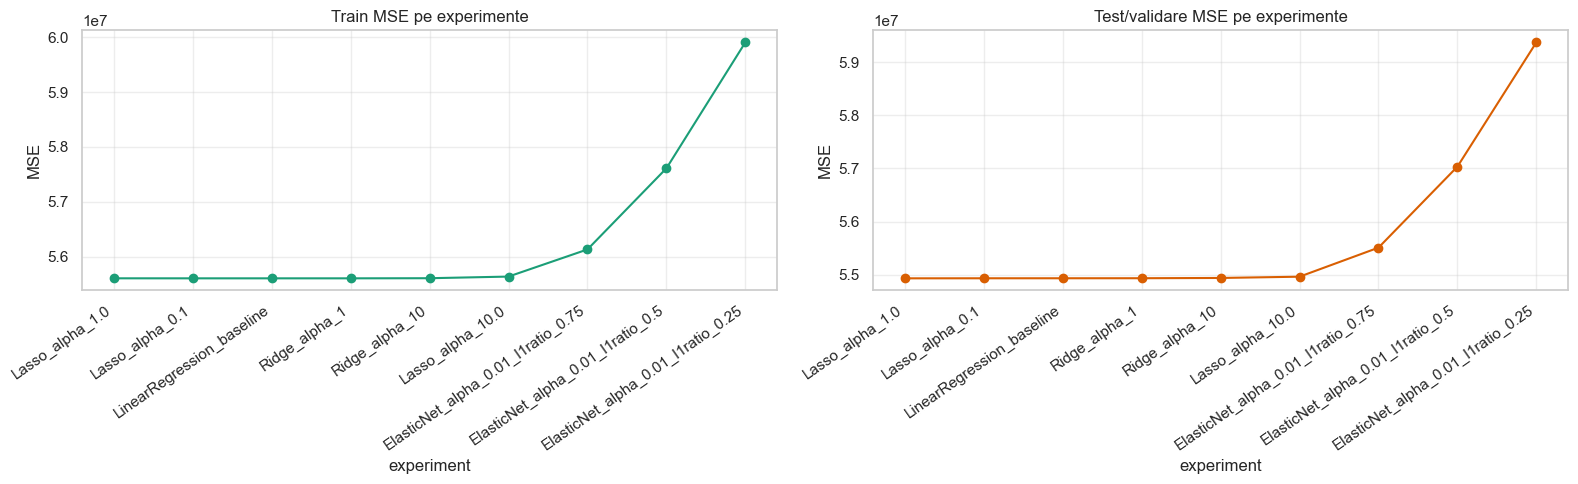

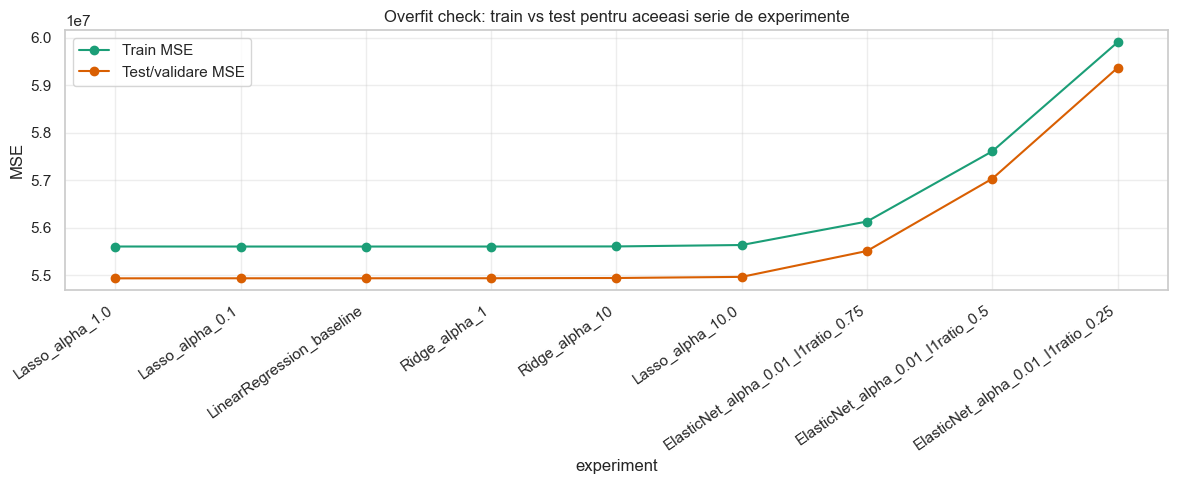

Curba de validare pentru etapele B4 de perfectionare:


,stage_idx,stage,test_MSE,test_RMSE,test_MAE,public_note
0,1,Stage 1 - CatBoost pseudo,2.810240e+07,5301.169674,4232.878415,intermediar; a devenit sursa pseudo
1,2,Stage 2 - LGBM pseudo,2.906952e+07,5391.615818,4307.281481,intermediar; LGBM separat
2,3,Stage 2b - CatBoost + LGBM blend,2.798396e+07,5289.986816,4225.256363,~271.9M public pentru blendul Cat/LGBM
3,4,Stage 3 - LGBM seed ensemble,2.884600e+07,5370.846870,4289.583180,268.447M public
4,5,Stage 4 - away fata de blend Cat/LGBM,2.887864e+07,5373.884771,4291.938209,268.429M public
5,6,Stage 5 model - aggbins dropraw,2.929089e+07,5412.105462,4319.674806,
6,7,Stage 5 - aggbins dropraw 75%,2.893485e+07,5379.111926,4293.961565,268.241M public
7,8,Stage 6 model - V2 dropcert,2.922210e+07,5405.747344,4312.535332,
8,9,Stage 6 - V2 dropcert 20% final,2.875333e+07,5362.213622,4281.298259,"~268.1M public, final ales"


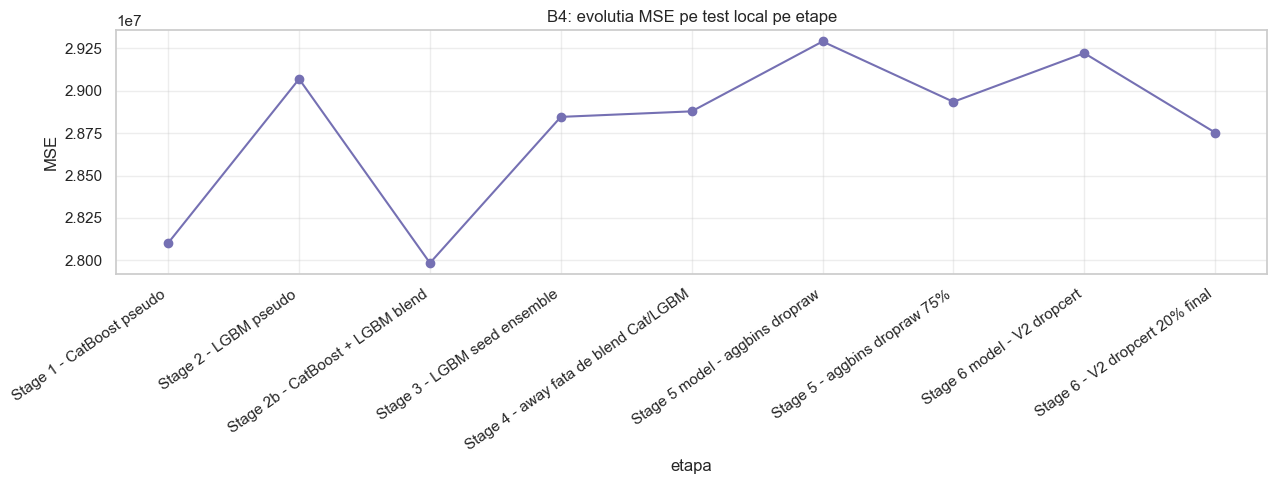

In [27]:
curve_source_df = regression_model_comparison.dropna(subset=["train_MSE", "test_MSE"]).copy()
curve_source_df = curve_source_df.reset_index(drop=True).head(10)
curve_source_df["experiment_idx"] = np.arange(1, len(curve_source_df) + 1)

print("Curbe pentru modelele locale cu metrici train si test disponibile:")
display(curve_source_df[["experiment_idx", "model", "train_MSE", "test_MSE", "test_RMSE", "test_MAE", "test_R2"]])

if PLOTS_AVAILABLE and not curve_source_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    axes[0].plot(curve_source_df["experiment_idx"], curve_source_df["train_MSE"], marker="o", color="#1b9e77")
    axes[0].set_title("Train MSE pe experimente")
    axes[0].set_ylabel("MSE")
    axes[0].set_xlabel("experiment")
    axes[0].grid(True, alpha=0.35)

    axes[1].plot(curve_source_df["experiment_idx"], curve_source_df["test_MSE"], marker="o", color="#d95f02")
    axes[1].set_title("Test/validare MSE pe experimente")
    axes[1].set_ylabel("MSE")
    axes[1].set_xlabel("experiment")
    axes[1].grid(True, alpha=0.35)

    for ax in axes:
        ax.set_xticks(curve_source_df["experiment_idx"])
        ax.set_xticklabels(curve_source_df["model"], rotation=35, ha="right")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(curve_source_df["experiment_idx"], curve_source_df["train_MSE"], marker="o", label="Train MSE", color="#1b9e77")
    ax.plot(curve_source_df["experiment_idx"], curve_source_df["test_MSE"], marker="o", label="Test/validare MSE", color="#d95f02")
    ax.set_title("Overfit check: train vs test pentru aceeasi serie de experimente")
    ax.set_ylabel("MSE")
    ax.set_xlabel("experiment")
    ax.set_xticks(curve_source_df["experiment_idx"])
    ax.set_xticklabels(curve_source_df["model"], rotation=35, ha="right")
    ax.grid(True, alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()

stage_curve_df = regression_stage_df[["stage", "test_MSE", "test_RMSE", "test_MAE", "public_note"]].copy()
stage_curve_df["stage_idx"] = np.arange(1, len(stage_curve_df) + 1)
print("Curba de validare pentru etapele B4 de perfectionare:")
display(stage_curve_df[["stage_idx", "stage", "test_MSE", "test_RMSE", "test_MAE", "public_note"]])

if PLOTS_AVAILABLE and not stage_curve_df.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(stage_curve_df["stage_idx"], stage_curve_df["test_MSE"], marker="o", color="#7570b3")
    ax.set_title("B4: evolutia MSE pe test local pe etape")
    ax.set_ylabel("MSE")
    ax.set_xlabel("etapa")
    ax.set_xticks(stage_curve_df["stage_idx"])
    ax.set_xticklabels(stage_curve_df["stage"], rotation=35, ha="right")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()


## B6. Analiza erorilor pe test local

Pentru analiza calitativa folosesc ultima etapa aleasa pentru Kaggle, dar pe predicțiile locale calculate in B4. Asa se vede cum se comporta finalul pe `test_raw`, chiar daca decizia de leaderboard a folosit si feedback Kaggle.


In [28]:
error_df = test_raw[BASE_FEATURES].copy()
error_df["salary_true"] = y_test.values
error_df["salary_pred"] = best_regression_prediction_local
error_df["error"] = error_df["salary_pred"] - error_df["salary_true"]
error_df["abs_error"] = error_df["error"].abs()
error_df["squared_error"] = error_df["error"] ** 2
error_df["salary_bin"] = pd.qcut(error_df["salary_true"], q=5, duplicates="drop")

print("Model final analizat local:", best_regression_name)
display(error_df.sort_values("squared_error", ascending=False).head(10))
display(error_df.groupby("salary_bin", observed=False).agg(
    count=("abs_error", "count"),
    MAE=("abs_error", "mean"),
    MSE=("squared_error", "mean"),
    max_abs_error=("abs_error", "max"),
).round(2))



Model final analizat local: Stage 6 - V2 dropcert 20% final


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,aggregated_score,skill_bracket,salary_true,salary_pred,error,abs_error,squared_error,salary_bin
14713,Machine Learning Engineer,9,Master,63,Telecom,Large,Canada,NaN,5,0.312257,low,182364,205718.233920,23354.233920,23354.233920,5.454202e+08,"(176033.6, 296998.0]"
11913,Data Scientist,6,PhD,11,Manufacturing,Enterprise,Australia,NaN,2,-0.017035,mid,149530,172250.044236,22720.044236,22720.044236,5.162004e+08,"(134038.4, 152483.2]"
13146,AI Engineer,20,PhD,64,Manufacturing,Small,USA,Yes,0,1.118858,high,270596,248169.870304,-22426.129696,22426.129696,5.029313e+08,"(176033.6, 296998.0]"
6882,Frontend Developer,17,Bachelor,10,Retail,Small,Canada,NaN,5,0.355430,mid,142766,162874.297394,20108.297394,20108.297394,4.043436e+08,"(134038.4, 152483.2]"
5728,Product Manager,1,High School,4,Telecom,Medium,India,NaN,2,-0.026891,low,92856,72758.380283,-20097.619717,20097.619717,4.039143e+08,"(37212.999, 113760.6]"
11998,Data Scientist,16,PhD,1,Government,Enterprise,UK,NaN,0,-1.724331,low,197859,217487.691974,19628.691974,19628.691974,3.852855e+08,"(176033.6, 296998.0]"
15061,DevOps Engineer,20,PhD,6,Healthcare,Small,Australia,Yes,3,0.280088,low,192403,173075.385381,-19327.614619,19327.614619,3.735567e+08,"(176033.6, 296998.0]"
11493,Business Analyst,4,Diploma,3,Retail,Small,Singapore,NaN,3,-0.998462,low,63221,82487.186772,19266.186772,19266.186772,3.711860e+08,"(37212.999, 113760.6]"
569,Data Scientist,14,High School,2,Technology,Enterprise,Germany,NaN,3,1.940492,low,149707,168727.509230,19020.509230,19020.509230,3.617798e+08,"(134038.4, 152483.2]"
2459,Cloud Engineer,9,Master,9,Education,Small,Canada,No,1,0.446767,mid,145359,164108.555482,18749.555482,18749.555482,3.515458e+08,"(134038.4, 152483.2]"


,count,MAE,MSE,max_abs_error
salary_bin,,,,
"(37212.999, 113760.6]",3200,4273.99,28667502.58,20097.62
"(113760.6, 134038.4]",3200,4114.24,26484355.91,17068.57
"(134038.4, 152483.2]",3200,4289.89,28999300.85,22720.04
"(152483.2, 176033.6]",3200,4256.12,28445169.91,18457.02
"(176033.6, 296998.0]",3200,4472.25,31170345.42,23354.23


## B7. Verificarea submission-ului de regresie

La final verific ca submission-ul generat in B4.6 are exact formatul cerut: coloanele `id,prediction`, id-uri unice si predictii nenule. Verificarea foloseste variabila `final_regression` creata in notebook, nu citeste un CSV vechi dintr-un folder auxiliar.


In [29]:
assert list(final_regression.columns) == ["id", "prediction"]
assert final_regression["id"].is_unique
assert final_regression["prediction"].notna().all()

if private_test_raw is not None:
    assert len(final_regression) == len(private_test_raw)
    assert set(final_regression["id"]) == set(private_test_raw["id"])
    assert (SUBMISSIONS_DIR / "submission_regression_final.csv").exists()

print("Regression final OK:", final_regression.shape)
display(final_regression.head())
display(final_regression["prediction"].describe().to_frame("prediction"))


Regression final OK: (16000, 2)


,id,prediction
0,1,154183.100282
1,2,137462.565262
2,3,114294.234209
3,4,119454.773096
4,5,128000.460862


,prediction
count,16000.000000
mean,156985.466736
std,35554.853268
min,42531.874162
25%,131435.269873
50%,155106.631572
75%,183137.816238
max,311244.939836


# PARTEA C - CLASIFICARE

Tinta de clasificare este `vacation`, cu clasele `No Vacation`, `Small`, `Medium`, `Large`.

In partea de clasificare vreau sa se vada un fir simplu si sustenabil la prezentare:

- pornesc de la un baseline interpretabil, `DecisionTreeClassifier`;
- variez hiperparametri ai arborelui ca sa vad efectul underfit/overfit;
- trec la modele mai stabile pentru date tabelare, dar pastrez aceeasi schema de evaluare locala;
- aleg finalul dupa metricile de pe `CC_education_economy_test.csv`, apoi refac antrenarea pe `train + test local` pentru submission.

Reperele de punctaj urmarite aici:

- baseline cu `DecisionTreeClassifier`;
- variatie de hiperparametru pentru arbore;
- encodare explicita pentru atributele categorice;
- tabel cu accuracy, precision, recall si F1;
- matrice de confuzie pentru modelele importante;
- o etapa de perfectionare cu modele potrivite pentru date tabelare.

Nu folosesc `salary` in clasificare: lipseste din `CC_private_test.csv`, deci folosirea lui ar insemna leakage.


## C1. EDA specific pentru clasificare

In aceasta sectiune verific echilibrul claselor si relatia dintre `vacation` si cateva atribute importante. Observatia de pornire este ca setul este dezechilibrat: `No Vacation` apare mult mai des decat clasele `Small`, `Medium` si `Large`. Din cauza asta nu ma uit doar la `accuracy`; un model poate parea bun daca prezice des clasa majoritara, dar poate rata clasele mai mici.

De aici vine decizia de mai jos: in toate modelele afisez si `precision`, `recall`, `F1 macro` si `F1 weighted`, iar pentru modelele importante verific matricea de confuzie.


,count,percent
vacation,,
No Vacation,34686,54.20
Small,12877,20.12
Medium,8527,13.32
Large,7910,12.36


,experience_years,skills_count,certifications,total_days_worked,aggregated_score
vacation,,,,,
Large,14.651,11.862,2.563,3515.987,-0.003
Medium,12.789,11.426,2.516,3069.318,-0.012
No Vacation,7.701,11.558,2.489,1848.083,0.007
Small,11.357,11.688,2.535,2725.666,-0.004


,feature,corr_with_vacation_code
0,experience_years,-0.232
3,total_days_worked,-0.232
2,certifications,-0.006
1,skills_count,-0.002
4,aggregated_score,0.002



Distributie education_level conditionata de vacation (% pe rand):


education_level,Bachelor,Diploma,High School,Master,PhD
vacation,,,,,
Large,8.67,3.88,1.98,26.71,58.75
Medium,16.89,11.23,6.22,28.84,36.82
No Vacation,22.90,27.12,30.68,13.46,5.84
Small,21.69,16.18,11.47,27.72,22.95


...

company_size,Enterprise,Large,Medium,Small,Startup
vacation,,,,,
Large,46.16,31.05,11.35,5.83,5.61
Medium,32.13,28.02,16.41,11.76,11.68
No Vacation,9.84,14.22,22.62,26.82,26.51
Small,23.41,24.52,20.47,16.14,15.46



Distributie remote_work conditionata de vacation (% pe rand):


remote_work,Hybrid,Missing,No,Yes
vacation,,,,
Large,26.73,32.90,24.73,15.65
Medium,24.97,32.24,24.37,18.42
No Vacation,22.28,28.42,22.63,26.67
Small,23.95,30.64,23.85,21.57



Distributie job_title conditionata de vacation (% pe rand):


job_title,AI Engineer,Backend Developer,Business Analyst,Cloud Engineer,Cybersecurity Analyst,Data Analyst,Data Scientist,DevOps Engineer,Frontend Developer,Machine Learning Engineer,Product Manager,Software Engineer
vacation,,,,,,,,,,,,
Large,9.84,7.83,7.62,8.50,8.38,7.35,8.45,8.77,7.60,9.27,8.38,8.03
Medium,8.83,8.37,7.73,8.35,7.95,7.66,8.50,8.36,8.17,8.67,8.87,8.54
No Vacation,7.97,8.37,8.64,8.20,8.48,8.65,8.40,8.23,8.55,8.01,8.10,8.41
Small,8.66,8.96,8.17,8.33,8.34,8.26,8.36,8.42,8.02,8.44,8.34,7.70


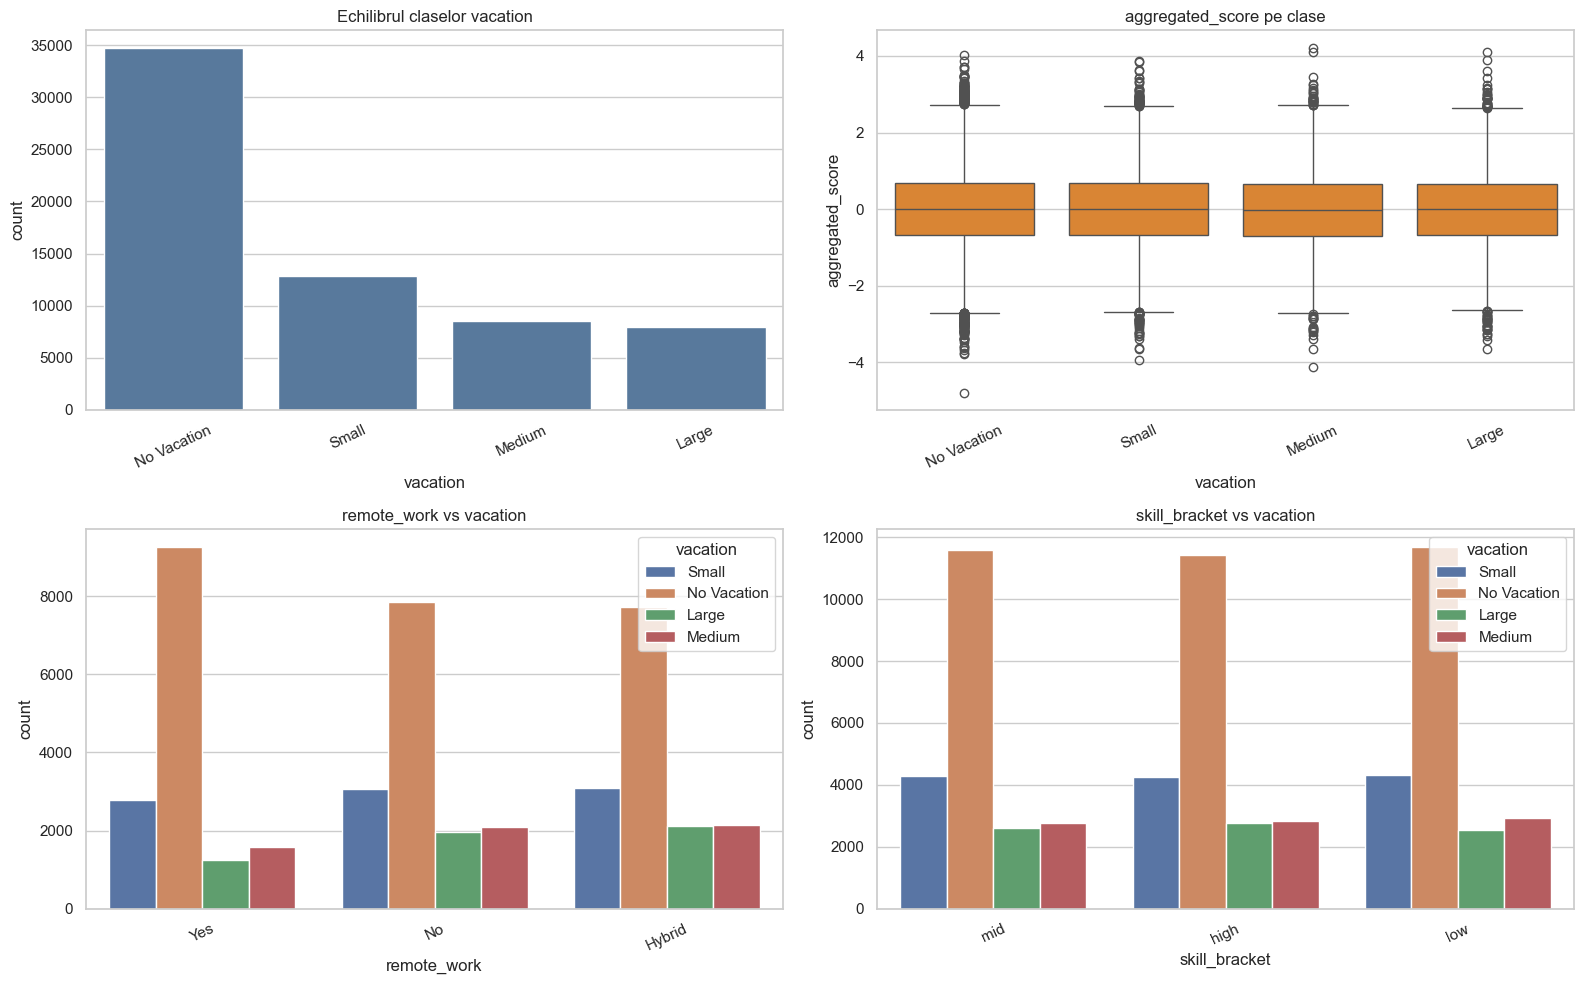

In [30]:
classification_balance = pd.concat([
    train_raw[CLASSIFICATION_TARGET].value_counts().rename("count"),
    (train_raw[CLASSIFICATION_TARGET].value_counts(normalize=True) * 100).round(2).rename("percent")
], axis=1)

display(classification_balance)

classification_numeric_cols = [
    c for c in ["experience_years", "skills_count", "certifications", "total_days_worked", "aggregated_score"]
    if c in train_raw.columns
]
classification_numeric_by_class = train_raw.groupby(CLASSIFICATION_TARGET)[classification_numeric_cols].mean().round(3)
display(classification_numeric_by_class)

classification_target_encoded = train_raw[CLASSIFICATION_TARGET].astype("category").cat.codes
classification_numeric_relation = pd.DataFrame({
    "feature": classification_numeric_cols,
    "corr_with_vacation_code": [train_raw[c].corr(classification_target_encoded) for c in classification_numeric_cols],
}).sort_values("corr_with_vacation_code", key=lambda s: s.abs(), ascending=False)
display(classification_numeric_relation.round(3))

for col in ["education_level", "skill_bracket", "company_size", "remote_work", "job_title"]:
    if col in train_raw.columns:
        print()
        print(f"Distributie {col} conditionata de vacation (% pe rand):")
        display((pd.crosstab(train_raw[CLASSIFICATION_TARGET], train_raw[col].fillna("Missing"), normalize="index") * 100).round(2))

if PLOTS_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    sns.countplot(x=train_raw[CLASSIFICATION_TARGET], order=classification_balance.index, ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].set_title("Echilibrul claselor vacation")
    axes[0, 0].tick_params(axis="x", rotation=25)

    sns.boxplot(data=train_raw, x=CLASSIFICATION_TARGET, y="aggregated_score", order=classification_balance.index, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("aggregated_score pe clase")
    axes[0, 1].tick_params(axis="x", rotation=25)

    sns.countplot(data=train_raw, x="remote_work", hue=CLASSIFICATION_TARGET, ax=axes[1, 0])
    axes[1, 0].set_title("remote_work vs vacation")
    axes[1, 0].tick_params(axis="x", rotation=25)

    sns.countplot(data=train_raw, x="skill_bracket", hue=CLASSIFICATION_TARGET, ax=axes[1, 1])
    axes[1, 1].set_title("skill_bracket vs vacation")
    axes[1, 1].tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()


## C2. Preprocesare pentru clasificare

Partea A este EDA general: acolo doar observ tipuri de date, lipsuri si distributii, nu modific efectiv dataset-ul folosit de modele. Preprocesarea reala se face in pipeline-urile fiecarui task. Pentru clasificare, aceasta este prima celula in care definesc efectiv transformarea datelor.

Preprocesarea de clasificare este similara ca principiu cu regresia, dar nu este copiata mecanic. Aici tinta este `vacation`, iar `salary` este eliminat fiindca lipseste din `CC_private_test.csv` si ar produce leakage.

Pentru baseline si modelele sklearn folosesc:

- doar coloane disponibile si in `CC_private_test.csv`;
- eliminare `salary`, pentru evitarea leakage-ului;
- imputare cu mediana pentru numerice;
- imputare cu `Missing` si `OneHotEncoder` pentru categorice;
- `LabelEncoder` pentru tinta `vacation`.

Clarificare importanta pentru `remote_work`: valorile lipsa sunt tratate aici, in preprocesarea de clasificare, prin categoria `Missing`. Nu exista o preprocesare globala anterioara care sa schimbe datele in locul acestei celule. In C4 testez doar o idee suplimentara de feature engineering: pe langa categoria `Missing`, adaug un indicator numeric `remote_work_missing` ca sa vad daca simplul fapt ca valoarea lipseste are semnal predictiv separat. Este o incercare mica de ablation, nu o etapa noua de curatare.


In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

CLASSIFICATION_FEATURES = [
    c for c in train_raw.columns
    if c != CLASSIFICATION_TARGET and private_test_raw is not None and c in private_test_raw.columns
]
CLASSIFICATION_FEATURES = [c for c in CLASSIFICATION_FEATURES if c != REGRESSION_TARGET]

X_train_classification = train_raw[CLASSIFICATION_FEATURES].copy()
y_train_classification_raw = train_raw[CLASSIFICATION_TARGET].copy()
X_test_classification = test_raw[CLASSIFICATION_FEATURES].copy()
y_test_classification_raw = test_raw[CLASSIFICATION_TARGET].copy()

CLASSIFICATION_NUM_COLS = X_train_classification.select_dtypes(include=[np.number]).columns.tolist()
CLASSIFICATION_CAT_COLS = [c for c in X_train_classification.columns if c not in CLASSIFICATION_NUM_COLS]

classification_label_encoder = LabelEncoder()
y_train_classification = classification_label_encoder.fit_transform(y_train_classification_raw)
y_test_classification = classification_label_encoder.transform(y_test_classification_raw)

classification_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), CLASSIFICATION_NUM_COLS),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", make_one_hot_encoder()),
    ]), CLASSIFICATION_CAT_COLS),
])

print("Features clasificare:", CLASSIFICATION_FEATURES)
print("Numerice:", CLASSIFICATION_NUM_COLS)
print("Categorice:", CLASSIFICATION_CAT_COLS)
print("Clase vacation:", list(classification_label_encoder.classes_))


Features clasificare: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications', 'total_days_worked', 'aggregated_score', 'skill_bracket']
Numerice: ['experience_years', 'skills_count', 'certifications', 'total_days_worked', 'aggregated_score']
Categorice: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'skill_bracket']
Clase vacation: ['Large', 'Medium', 'No Vacation', 'Small']


## C3. Baseline DecisionTreeClassifier si variatie de hiperparametri

Pornesc de la un `DummyClassifier`, ca reper de underfit: acesta arata ce obtinem daca nu invatam aproape nimic si prezicem clasa majoritara. Apoi antrenez arbori de decizie cu valori diferite pentru `max_depth` si `min_samples_leaf`.

Motivul pentru acesti hiperparametri este usor de sustinut la prezentare: `max_depth` controleaza cat de complex poate deveni arborele, iar `min_samples_leaf` controleaza cat de mici pot fi frunzele. Daca frunzele sunt prea mici, arborele poate memora zgomot; daca sunt prea mari, modelul devine prea rigid. Aici vreau sa vad local unde apare un echilibru decent.


In [32]:
classification_results = []
CLASSIFICATION_SELECTED_DIR = CLASSIFICATION_RESULTS_DIR
CLASSIFICATION_SELECTED_DIR.mkdir(parents=True, exist_ok=True)
classification_predictions = {}
classification_train_predictions = {}
classification_models = {}
classification_model_notes = {}


def classification_metrics_from_predictions(name, test_pred, train_pred=None, note=""):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test_classification, test_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test_classification, test_pred, average="weighted", zero_division=0
    )
    row = {
        "model": name,
        "train_accuracy": accuracy_score(y_train_classification, train_pred) if train_pred is not None else np.nan,
        "accuracy": accuracy_score(y_test_classification, test_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "note": note,
    }
    classification_results[:] = [r for r in classification_results if r["model"] != name]
    classification_results.append(row)
    classification_predictions[name] = np.asarray(test_pred, dtype=int)
    if train_pred is not None:
        classification_train_predictions[name] = np.asarray(train_pred, dtype=int)
    classification_model_notes[name] = note
    return row


def classification_metric_row(name, model, note=""):
    model.fit(X_train_classification, y_train_classification)
    train_pred = model.predict(X_train_classification)
    test_pred = model.predict(X_test_classification)
    classification_models[name] = model
    return classification_metrics_from_predictions(name, test_pred, train_pred=train_pred, note=note)

classification_metric_row(
    "Dummy_most_frequent",
    DummyClassifier(strategy="most_frequent"),
    note="underfit: prezice mereu clasa majoritara",
)

for max_depth, min_leaf in [(4, 20), (8, 30), (None, 100)]:
    clf = Pipeline([
        ("preprocess", classification_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ])
    classification_metric_row(
        f"DecisionTree_depth{max_depth}_leaf{min_leaf}",
        clf,
        note=f"baseline arbore: max_depth={max_depth}, min_samples_leaf={min_leaf}",
    )

classification_baseline_df = pd.DataFrame(classification_results).sort_values("accuracy", ascending=False)
classification_baseline_df.to_csv(CLASSIFICATION_SELECTED_DIR / "classification_baseline_results.csv", index=False)
display(classification_baseline_df)

best_tree_name = classification_baseline_df[classification_baseline_df["model"].str.startswith("DecisionTree")].iloc[0]["model"]
best_tree_pred = classification_predictions[best_tree_name]
print("Cel mai bun arbore baseline:", best_tree_name)
display(pd.DataFrame(
    confusion_matrix(y_test_classification, best_tree_pred),
    index=classification_label_encoder.classes_,
    columns=classification_label_encoder.classes_,
))
print(classification_report(
    y_test_classification,
    best_tree_pred,
    target_names=classification_label_encoder.classes_,
    zero_division=0,
))

# Pastrez baseline-ul in memorie; fisierul final se genereaza in C5 din modelul final ales.
if private_test_raw is not None:
    best_tree_model = classification_models[best_tree_name]
    private_tree_pred_encoded = best_tree_model.predict(private_test_raw[CLASSIFICATION_FEATURES])
    private_tree_pred = classification_label_encoder.inverse_transform(private_tree_pred_encoded)
    classification_baseline_submission = pd.DataFrame({
        "id": private_test_raw["id"],
        "prediction": private_tree_pred,
    })
    classification_baseline_submission.to_csv(CLASSIFICATION_SELECTED_DIR / "submission_classification_baseline.csv", index=False)
    display(classification_baseline_submission.head())


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
3,DecisionTree_depthNone_leaf100,0.731750,0.725562,0.665509,0.679052,0.668566,0.757657,0.725562,0.737356,"baseline arbore: max_depth=None, min_samples_l..."
2,DecisionTree_depth8_leaf30,0.716547,0.710063,0.655355,0.669302,0.656981,0.752298,0.710063,0.724801,"baseline arbore: max_depth=8, min_samples_leaf=30"
1,DecisionTree_depth4_leaf20,0.661375,0.661438,0.602970,0.546132,0.532526,0.659416,0.661438,0.632271,"baseline arbore: max_depth=4, min_samples_leaf=20"
0,Dummy_most_frequent,0.541969,0.542000,0.135500,0.250000,0.175746,0.293764,0.542000,0.381017,underfit: prezice mereu clasa majoritara


Cel mai bun arbore baseline: DecisionTree_depthNone_leaf100


,Large,Medium,No Vacation,Small
Large,1456,414,55,52
Medium,391,1188,68,485
No Vacation,12,73,6975,1612
Small,49,729,451,1990


              precision    recall  f1-score   support

       Large       0.76      0.74      0.75      1977
      Medium       0.49      0.56      0.52      2132
 No Vacation       0.92      0.80      0.86      8672
       Small       0.48      0.62      0.54      3219

    accuracy                           0.73     16000
   macro avg       0.67      0.68      0.67     16000
weighted avg       0.76      0.73      0.74     16000



,id,prediction
0,1,Small
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


## C4. Perfectionare clasificare - istoric reproductibil

Dupa baseline-ul cu arbore, pastrez un jurnal scurt al incercarilor importante, in aceeasi logica in care am refacut regresia: un model la fiecare pas, rezultate locale pe `CC_education_economy_test.csv`, apoi alegerea finala pentru private test.

Firul meu de gandire este acesta:

1. Daca un singur arbore este sensibil la split-uri, incerc ensemble-uri de arbori (`RandomForest`, `ExtraTrees`) ca sa reduc varianta.
2. Daca ensemble-urile de arbori ajuta, incerc boosting (`HistGradientBoosting`, `LightGBM`), deoarece boosting-ul corecteaza iterativ greselile anterioare si este puternic pe date tabelare.
3. Pentru ca multe features sunt categoriale, incerc `CatBoost`, care poate trata categoricele nativ, fara sa sparga totul in multe coloane OneHot.
4. Pentru Kaggle verific driftul fata de `CC_private_test.csv`, la fel ca in regresie. La clasificare nu pot face pseudo-labeling sigur pe clase fara sa risc sa intaresc greseli, asa ca folosesc adversarial/domain weights si calibrare de prior.

Nu citesc rezultate vechi din CSV-uri auxiliare. Tot ce se afiseaza mai jos este antrenat in celulele notebook-ului.


### C4.1. Helperi pentru etapele de clasificare

Aici definesc functiile comune pentru modelele mai puternice si pentru tabelul de metrici cerut in PDF. Le pun intr-o singura celula ca sa nu repet codul de evaluare si ca fiecare etapa de mai jos sa arate doar ideea experimentului: ce model incerc si de ce.


In [33]:
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split, StratifiedKFold

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

classification_model_specs = {}
classification_stage_rows = []


def make_one_hot_encoder_dense():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_classification_preprocessor_for(frame: pd.DataFrame, dense=False):
    num_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in frame.columns if c not in num_cols]
    categorical_encoder = make_one_hot_encoder_dense() if dense else make_one_hot_encoder()
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", categorical_encoder),
        ]), cat_cols),
    ])


def identity_features(df: pd.DataFrame) -> pd.DataFrame:
    return df.copy()


def evaluate_sklearn_classifier(name, model_factory, note, feature_builder=identity_features, dense=False):
    X_train_stage = feature_builder(X_train_classification)
    X_test_stage = feature_builder(X_test_classification)
    model = Pipeline([
        ("preprocess", make_classification_preprocessor_for(X_train_stage, dense=dense)),
        ("model", model_factory()),
    ])
    model.fit(X_train_stage, y_train_classification)
    train_pred = model.predict(X_train_stage)
    test_pred = model.predict(X_test_stage)

    row = classification_metrics_from_predictions(name, test_pred, train_pred=train_pred, note=note)
    classification_models[name] = model
    classification_model_specs[name] = {
        "kind": "sklearn",
        "model_factory": model_factory,
        "feature_builder": feature_builder,
        "dense": dense,
        "note": note,
    }
    classification_stage_rows.append(row)
    display(pd.DataFrame([row]))
    return row


def prepare_catboost_frame(df: pd.DataFrame):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in out.columns if c not in num_cols]
    for col in cat_cols:
        out[col] = out[col].astype("object").where(out[col].notna(), "Missing").astype(str)
    return out, cat_cols


def make_catboost_classifier(seed=RANDOM_STATE, iterations=420):
    return CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="Accuracy",
        iterations=iterations,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=5,
        random_seed=seed,
        allow_writing_files=False,
        verbose=False,
    )


def evaluate_catboost_classifier(name, note, feature_builder=identity_features, seeds=(RANDOM_STATE,), iterations=420):
    if not CATBOOST_AVAILABLE:
        print(f"Sar peste {name}: catboost nu este instalat in mediu.")
        return None

    X_train_stage = feature_builder(X_train_classification)
    X_test_stage = feature_builder(X_test_classification)
    X_train_cb, cat_cols = prepare_catboost_frame(X_train_stage)
    X_test_cb, _ = prepare_catboost_frame(X_test_stage)

    test_probabilities = []
    train_probabilities = []
    fitted_models = []
    for seed in seeds:
        model = make_catboost_classifier(seed=seed, iterations=iterations)
        model.fit(X_train_cb, y_train_classification, cat_features=cat_cols)
        train_probabilities.append(model.predict_proba(X_train_cb))
        test_probabilities.append(model.predict_proba(X_test_cb))
        fitted_models.append(model)

    train_pred = np.mean(train_probabilities, axis=0).argmax(axis=1)
    test_pred = np.mean(test_probabilities, axis=0).argmax(axis=1)

    row = classification_metrics_from_predictions(name, test_pred, train_pred=train_pred, note=note)
    classification_models[name] = {"models": fitted_models, "cat_cols": cat_cols}
    classification_model_specs[name] = {
        "kind": "catboost",
        "feature_builder": feature_builder,
        "seeds": tuple(seeds),
        "iterations": iterations,
        "note": note,
    }
    classification_stage_rows.append(row)
    display(pd.DataFrame([row]))
    return row


def add_classification_fe(df: pd.DataFrame, drop_agg=False, drop_cert=False):
    out = df.copy()

    # Missing-ul din remote_work este deja imputat ca "Missing" in pipeline.
    # Indicatorul separat testeaza doar daca lipsa in sine are semnal predictiv.
    if "remote_work" in out.columns:
        out["remote_work_missing"] = out["remote_work"].isna().astype("int8")

    if "aggregated_score" in out.columns:
        out["aggregated_score_bin"] = pd.cut(
            out["aggregated_score"],
            bins=[-np.inf, -1.25, -0.5, 0.0, 0.5, 1.25, np.inf],
            labels=["very_low", "low", "slightly_low", "slightly_high", "high", "very_high"],
            include_lowest=True,
        )

    if "skills_count" in out.columns:
        out["skills_count_bin"] = pd.cut(
            out["skills_count"],
            bins=[-np.inf, 5, 10, 15, 20, np.inf],
            labels=["very_low", "low", "mid", "high", "very_high"],
            include_lowest=True,
        )
        out["skills_count_gt25"] = (out["skills_count"] > 25).astype("int8")

    if "experience_years" in out.columns:
        out["experience_band"] = pd.cut(
            out["experience_years"],
            bins=[-np.inf, 2, 5, 10, 15, np.inf],
            labels=["junior", "early", "mid", "senior", "expert"],
            include_lowest=True,
        )

    if "certifications" in out.columns:
        out["certification_bucket"] = pd.cut(
            out["certifications"],
            bins=[-np.inf, 0, 1, 3, np.inf],
            labels=["none", "one", "few", "many"],
            include_lowest=True,
        )

    def combine(new_col, left, right):
        if left in out.columns and right in out.columns:
            left_values = out[left].astype("object").where(out[left].notna(), "Missing").astype(str)
            right_values = out[right].astype("object").where(out[right].notna(), "Missing").astype(str)
            out[new_col] = left_values + "__" + right_values

    combine("job_x_location", "job_title", "location")
    combine("job_x_remote", "job_title", "remote_work")
    combine("industry_x_location", "industry", "location")
    combine("job_x_experience_band", "job_title", "experience_band")
    combine("job_x_skills_bin", "job_title", "skills_count_bin")
    combine("job_x_cert_bucket", "job_title", "certification_bucket")

    if drop_agg and "aggregated_score" in out.columns:
        out = out.drop(columns=["aggregated_score"])
    if drop_cert and "certifications" in out.columns:
        out = out.drop(columns=["certifications"])

    return out


def classification_per_class_table(model_names):
    rows = []
    label_ids = np.arange(len(classification_label_encoder.classes_))
    for name in model_names:
        pred = classification_predictions[name]
        precisions, recalls, f1s, _ = precision_recall_fscore_support(
            y_test_classification, pred, labels=label_ids, zero_division=0
        )
        row = {"model": name, "accuracy": accuracy_score(y_test_classification, pred)}
        for class_name, precision_value, recall_value, f1_value in zip(
            classification_label_encoder.classes_, precisions, recalls, f1s
        ):
            safe_class = class_name.replace(" ", "_")
            row[f"precision_{safe_class}"] = precision_value
            row[f"recall_{safe_class}"] = recall_value
            row[f"f1_{safe_class}"] = f1_value
        rows.append(row)
    return pd.DataFrame(rows)


def classification_prior_from_labels(y_encoded):
    return np.bincount(y_encoded, minlength=len(classification_label_encoder.classes_)) / len(y_encoded)


def predict_with_prior_matching(proba, target_prior, steps=400, learning_rate=0.25):
    """Ajusteaza biasurile de clasa astfel incat distributia predictiilor sa urmeze un prior ales."""
    factors = np.ones(proba.shape[1], dtype=float)
    for _ in range(steps):
        pred = (proba * factors).argmax(axis=1)
        current_prior = np.bincount(pred, minlength=proba.shape[1]) / len(pred)
        factors *= (target_prior / (current_prior + 1e-9)) ** learning_rate
        factors /= np.exp(np.mean(np.log(factors)))
    return (proba * factors).argmax(axis=1), factors


def encoded_prediction_distribution(pred):
    return pd.Series(
        classification_label_encoder.inverse_transform(np.asarray(pred, dtype=int))
    ).value_counts(normalize=True).reindex(classification_label_encoder.classes_, fill_value=0)


def make_private_domain_weights(local_features: pd.DataFrame, private_features: pd.DataFrame, feature_cols, random_state=RANDOM_STATE):
    """Estimeaza cat de asemanator este fiecare rand local cu private test si intoarce weights de covariate shift."""
    if private_features is None or len(private_features) == 0:
        return np.ones(len(local_features)), np.nan, None

    X_local_domain = local_features[feature_cols].reset_index(drop=True).copy()
    X_private_domain = private_features[feature_cols].reset_index(drop=True).copy()
    X_domain = pd.concat([X_local_domain, X_private_domain], ignore_index=True)
    y_domain = np.r_[
        np.zeros(len(X_local_domain), dtype=int),
        np.ones(len(X_private_domain), dtype=int),
    ]

    X_domain_train, X_domain_valid, y_domain_train, y_domain_valid = train_test_split(
        X_domain,
        y_domain,
        test_size=0.25,
        stratify=y_domain,
        random_state=random_state,
    )
    domain_model = Pipeline([
        ("preprocess", make_classification_preprocessor_for(X_domain, dense=False)),
        ("model", RandomForestClassifier(
            n_estimators=180,
            max_depth=14,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )),
    ])
    domain_model.fit(X_domain_train, y_domain_train)
    domain_auc = roc_auc_score(y_domain_valid, domain_model.predict_proba(X_domain_valid)[:, 1])

    p_private = domain_model.predict_proba(X_local_domain)[:, 1]
    raw_weights = (p_private / (1.0 - p_private + 1e-6)) * (len(X_local_domain) / len(X_private_domain))
    weights = np.clip(raw_weights, 0.25, 4.0)
    weights = weights / weights.mean()
    return weights, domain_auc, domain_model


### C4.2. Stage 1 - ensemble-uri de arbori

Dupa `DecisionTreeClassifier`, incerc doua extensii naturale: `RandomForest` si `ExtraTrees`. Gandul meu aici este ca un singur arbore poate fi instabil: o mica schimbare in date poate schimba split-urile. Ensemble-urile combina mai multi arbori si ar trebui sa dea un rezultat mai stabil.

Daca aceste modele cresc peste baseline, inseamna ca relatiile nonlineare din date conteaza si merita mers mai departe cu modele tabelare mai puternice. Daca nu ar fi crescut, m-as fi intors la features si la encodare.


In [34]:
evaluate_sklearn_classifier(
    "RandomForest_balanced",
    lambda: RandomForestClassifier(
        n_estimators=160,
        max_depth=18,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    note="ensemble de arbori, class_weight balanced_subsample",
)

evaluate_sklearn_classifier(
    "ExtraTrees_balanced",
    lambda: ExtraTreesClassifier(
        n_estimators=180,
        max_depth=None,
        min_samples_leaf=8,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    note="arbori extrem de randomizati, utili ca verificare nonlineara",
)


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,RandomForest_balanced,0.812344,0.742812,0.67558,0.682346,0.677348,0.76083,0.742812,0.750096,"ensemble de arbori, class_weight balanced_subs..."


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,ExtraTrees_balanced,0.803203,0.74325,0.679245,0.688905,0.681849,0.765481,0.74325,0.75193,"arbori extrem de randomizati, utili ca verific..."


{'model': 'ExtraTrees_balanced',
 'train_accuracy': 0.803203125,
 'accuracy': 0.74325,
 'precision_macro': 0.6792445092155943,
 'recall_macro': 0.6889047069634379,
 'f1_macro': 0.6818491319420005,
 'precision_weighted': 0.7654805423431387,
 'recall_weighted': 0.74325,
 'f1_weighted': 0.7519303274019153,
 'note': 'arbori extrem de randomizati, utili ca verificare nonlineara'}

### C4.3. Stage 2 - boosting pe date tabelare

Apoi trec la boosting: `HistGradientBoostingClassifier` din sklearn si, daca este instalat, `LightGBM`. Alegerea vine din observatia ca arborii/ensemble-urile merg rezonabil, deci merita un model care construieste arbori secvential si incearca sa corecteze erorile ramase.

Aici urmaresc mai ales daca se imbunatateste `accuracy` fara sa cada prea mult `F1 macro`. Daca accuracy creste dar F1 macro scade, inseamna ca modelul ajuta clasa majoritara, dar pierde pe clasele mici.


In [35]:
evaluate_sklearn_classifier(
    "HistGradientBoosting",
    lambda: HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.06,
        max_leaf_nodes=31,
        l2_regularization=0.02,
        random_state=RANDOM_STATE,
    ),
    note="boosting sklearn pe features OneHot dense",
    dense=True,
)

if LIGHTGBM_AVAILABLE:
    evaluate_sklearn_classifier(
        "LightGBM_multiclass",
        lambda: LGBMClassifier(
            objective="multiclass",
            n_estimators=280,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        note="LightGBM multiclass cu OneHot, fara class_weight pentru accuracy local mai stabil",
    )
else:
    print("LightGBM nu este instalat; sar peste aceasta etapa.")


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,HistGradientBoosting,0.796531,0.761125,0.687337,0.669507,0.67768,0.753642,0.761125,0.756769,boosting sklearn pe features OneHot dense


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,LightGBM_multiclass,0.790344,0.760312,0.68577,0.667601,0.675928,0.75283,0.760312,0.75595,"LightGBM multiclass cu OneHot, fara class_weig..."


### C4.4. Stage 3 - CatBoost cu categorice native

CatBoost este o incercare logica dupa boosting, nu o saritura intamplatoare. Setul are multe coloane categoriale (`job_title`, `industry`, `location`, `remote_work`, `skill_bracket`), iar CatBoost este facut special sa lucreze bine cu astfel de date.

Aici verific daca tratarea nativa a categoricelor bate varianta OneHot folosita la modelele sklearn. Daca rezultatul este apropiat de boosting, concluzia este ca semnalul principal este deja capturat; daca ar fi mult mai bun, as merge mai mult in directia CatBoost.


In [36]:
evaluate_catboost_classifier(
    "CatBoost_native",
    note="CatBoostClassifier cu categorice native, fara feature engineering suplimentar",
    seeds=(RANDOM_STATE,),
    iterations=320,
)


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,CatBoost_native,0.764719,0.760625,0.689135,0.672155,0.680105,0.75643,0.760625,0.75814,"CatBoostClassifier cu categorice native, fara ..."


{'model': 'CatBoost_native',
 'train_accuracy': 0.76471875,
 'accuracy': 0.760625,
 'precision_macro': 0.6891353600146278,
 'recall_macro': 0.672155384797261,
 'f1_macro': 0.6801054041538288,
 'precision_weighted': 0.7564296103081547,
 'recall_weighted': 0.760625,
 'f1_weighted': 0.7581403238701153,
 'note': 'CatBoostClassifier cu categorice native, fara feature engineering suplimentar'}

### C4.5. Stage 4 - CatBoost data-centric V1 si ablation

Aici nu fac o noua curatare de missing. `remote_work` era deja tratat in C2 prin categoria `Missing`. Ce testez in plus este daca merita sa dau modelului si un indicator numeric separat, `remote_work_missing`, pentru ideea: "faptul ca informatia lipseste poate fi el insusi un semnal".

Pe langa asta adaug bins pentru scoruri si interactiuni intre job, locatie, industrie si nivelul experientei. M-am gandit la aceste features pentru ca `vacation` pare mai degraba legat de profilul angajatului si contextul jobului, nu doar de o singura coloana numerica izolata.

Ablation-ul are rolul sa nu fie doar "am adaugat multe lucruri si sper ca e bine": testez pastrarea raw, eliminarea lui `aggregated_score` raw si eliminarea lui `certifications` raw. Asa pot explica ce componenta a ajutat sau macar daca schimbarea nu aduce castig real.


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,CatBoost_V1_FE_keepraw,0.763391,0.759062,0.686247,0.667548,0.67608,0.754188,0.759062,0.75607,"FE V1 cu bins/interactiuni; drop_agg=False, dr..."


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,CatBoost_V1_FE_dropagg,0.763938,0.758875,0.685552,0.66531,0.674548,0.752753,0.758875,0.755173,"FE V1 cu bins/interactiuni; drop_agg=True, dro..."


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,CatBoost_V1_FE_dropcert,0.763656,0.757938,0.684334,0.664289,0.673428,0.751835,0.757938,0.754249,"FE V1 cu bins/interactiuni; drop_agg=False, dr..."


Tabel comparativ general:


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,HistGradientBoosting,0.7965,0.7611,0.6873,0.6695,0.6777,0.7536,0.7611,0.7568,boosting sklearn pe features OneHot dense
1,CatBoost_native,0.7647,0.7606,0.6891,0.6722,0.6801,0.7564,0.7606,0.7581,"CatBoostClassifier cu categorice native, fara ..."
2,LightGBM_multiclass,0.7903,0.7603,0.6858,0.6676,0.6759,0.7528,0.7603,0.7559,"LightGBM multiclass cu OneHot, fara class_weig..."
3,CatBoost_V1_FE_keepraw,0.7634,0.7591,0.6862,0.6675,0.6761,0.7542,0.7591,0.7561,"FE V1 cu bins/interactiuni; drop_agg=False, dr..."
4,CatBoost_V1_FE_dropagg,0.7639,0.7589,0.6856,0.6653,0.6745,0.7528,0.7589,0.7552,"FE V1 cu bins/interactiuni; drop_agg=True, dro..."
5,CatBoost_V1_FE_dropcert,0.7637,0.7579,0.6843,0.6643,0.6734,0.7518,0.7579,0.7542,"FE V1 cu bins/interactiuni; drop_agg=False, dr..."
6,ExtraTrees_balanced,0.8032,0.7432,0.6792,0.6889,0.6818,0.7655,0.7432,0.7519,"arbori extrem de randomizati, utili ca verific..."
7,RandomForest_balanced,0.8123,0.7428,0.6756,0.6823,0.6773,0.7608,0.7428,0.7501,"ensemble de arbori, class_weight balanced_subs..."
8,DecisionTree_depthNone_leaf100,0.7318,0.7256,0.6655,0.6791,0.6686,0.7577,0.7256,0.7374,"baseline arbore: max_depth=None, min_samples_l..."
9,DecisionTree_depth8_leaf30,0.7165,0.7101,0.6554,0.6693,0.6570,0.7523,0.7101,0.7248,"baseline arbore: max_depth=8, min_samples_leaf=30"


...

,model,accuracy,precision_Large,recall_Large,f1_Large,precision_Medium,recall_Medium,f1_Medium,precision_No_Vacation,recall_No_Vacation,f1_No_Vacation,precision_Small,recall_Small,f1_Small
0,HistGradientBoosting,0.761,0.777,0.741,0.759,0.543,0.481,0.510,0.874,0.917,0.895,0.555,0.539,0.547
1,CatBoost_native,0.761,0.792,0.732,0.761,0.534,0.496,0.515,0.879,0.910,0.894,0.551,0.550,0.551
2,LightGBM_multiclass,0.760,0.778,0.738,0.757,0.536,0.475,0.504,0.874,0.917,0.895,0.555,0.541,0.548
3,CatBoost_V1_FE_keepraw,0.759,0.790,0.733,0.760,0.531,0.470,0.499,0.878,0.912,0.895,0.545,0.555,0.550
4,CatBoost_V1_FE_dropagg,0.759,0.791,0.731,0.760,0.530,0.468,0.497,0.876,0.916,0.895,0.546,0.546,0.546
5,CatBoost_V1_FE_dropcert,0.758,0.789,0.731,0.759,0.528,0.466,0.495,0.875,0.915,0.895,0.544,0.546,0.545
6,ExtraTrees_balanced,0.743,0.777,0.747,0.761,0.510,0.553,0.531,0.921,0.834,0.875,0.509,0.622,0.560
7,RandomForest_balanced,0.743,0.770,0.740,0.754,0.508,0.536,0.521,0.914,0.844,0.877,0.511,0.610,0.556
8,DecisionTree_depthNone_leaf100,0.726,0.763,0.736,0.750,0.494,0.557,0.524,0.924,0.804,0.860,0.481,0.618,0.541
9,DecisionTree_depth8_leaf30,0.710,0.759,0.736,0.747,0.481,0.545,0.511,0.929,0.779,0.848,0.452,0.616,0.521


Maximul pe fiecare metrica din tabelul comparativ:


,metric,best_model,best_value
0,accuracy,HistGradientBoosting,0.7611
1,precision_Large,DecisionTree_depth4_leaf20,0.8614
2,recall_Large,ExtraTrees_balanced,0.7466
3,f1_Large,ExtraTrees_balanced,0.7614
4,precision_Medium,HistGradientBoosting,0.5434
5,recall_Medium,DecisionTree_depth4_leaf20,0.6703
6,f1_Medium,ExtraTrees_balanced,0.5308
7,precision_No_Vacation,DecisionTree_depth8_leaf30,0.9288
8,recall_No_Vacation,Dummy_most_frequent,1.0000
9,f1_No_Vacation,CatBoost_V1_FE_dropagg,0.8952


Model final ales pentru clasificare: HistGradientBoosting
Accuracy final local: 0.761125
Matrice de confuzie: DecisionTree_depthNone_leaf100


,Large,Medium,No Vacation,Small
Large,1456,414,55,52
Medium,391,1188,68,485
No Vacation,12,73,6975,1612
Small,49,729,451,1990


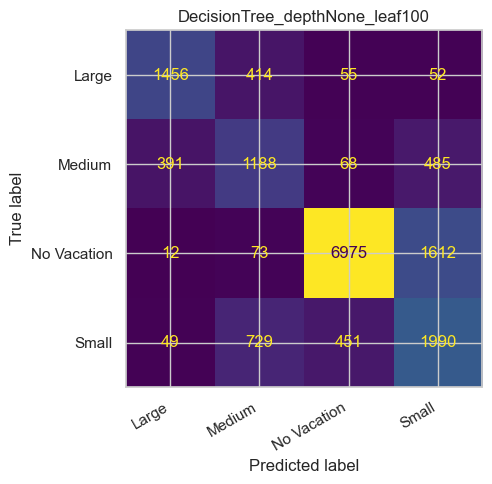

Matrice de confuzie: ExtraTrees_balanced


,Large,Medium,No Vacation,Small
Large,1476,400,50,51
Medium,368,1179,70,515
No Vacation,10,61,7236,1365
Small,46,670,502,2001


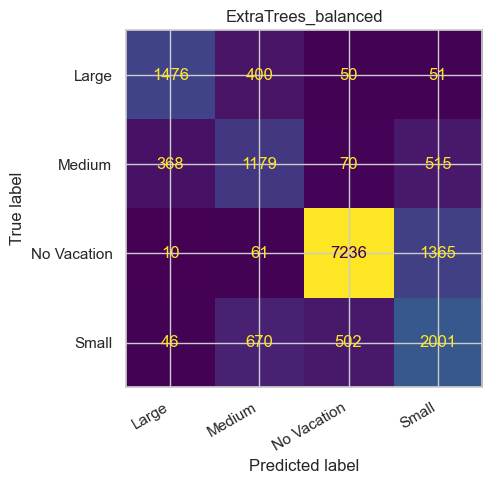

Matrice de confuzie: HistGradientBoosting


,Large,Medium,No Vacation,Small
Large,1465,376,63,73
Medium,364,1026,101,641
No Vacation,12,31,7953,676
Small,44,455,986,1734


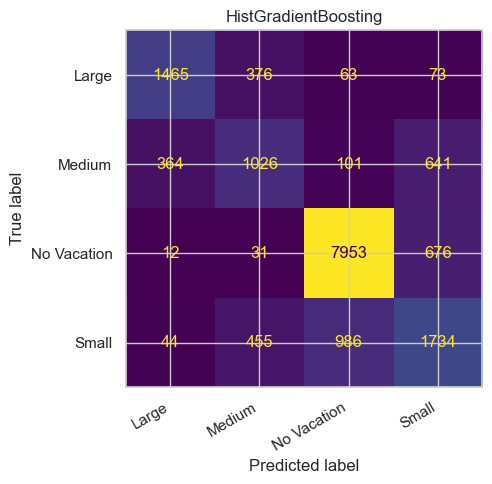

Matrice de confuzie: LightGBM_multiclass


,Large,Medium,No Vacation,Small
Large,1459,387,63,68
Medium,367,1012,101,652
No Vacation,10,35,7954,673
Small,40,453,986,1740


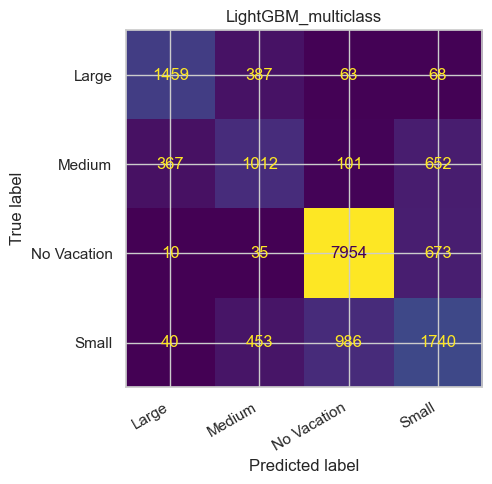

Matrice de confuzie: CatBoost_native


,Large,Medium,No Vacation,Small
Large,1447,408,61,61
Medium,334,1058,92,648
No Vacation,10,34,7894,734
Small,36,480,932,1771


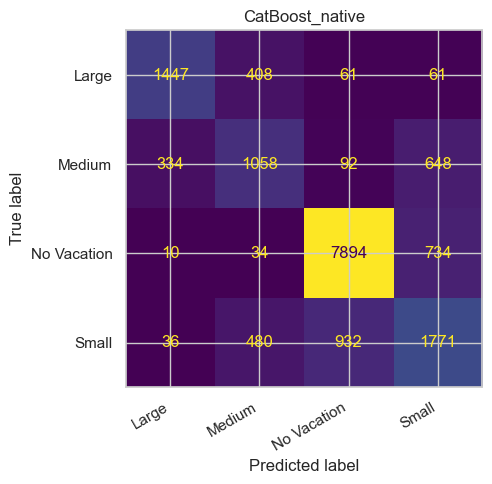

              precision    recall  f1-score   support

       Large       0.78      0.74      0.76      1977
      Medium       0.54      0.48      0.51      2132
 No Vacation       0.87      0.92      0.89      8672
       Small       0.56      0.54      0.55      3219

    accuracy                           0.76     16000
   macro avg       0.69      0.67      0.68     16000
weighted avg       0.75      0.76      0.76     16000



In [37]:
classification_fe_variants = [
    ("CatBoost_V1_FE_keepraw", {"drop_agg": False, "drop_cert": False}),
    ("CatBoost_V1_FE_dropagg", {"drop_agg": True, "drop_cert": False}),
    ("CatBoost_V1_FE_dropcert", {"drop_agg": False, "drop_cert": True}),
]

for variant_name, options in classification_fe_variants:
    evaluate_catboost_classifier(
        variant_name,
        note=f"FE V1 cu bins/interactiuni; drop_agg={options['drop_agg']}, drop_cert={options['drop_cert']}",
        feature_builder=lambda df, options=options: add_classification_fe(df, **options),
        seeds=(3,),
        iterations=360,
    )

classification_all_results_df = pd.DataFrame(classification_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
classification_all_results_df.to_csv(CLASSIFICATION_SELECTED_DIR / "classification_model_results.csv", index=False)
print("Tabel comparativ general:")
display(classification_all_results_df[[
    "model", "train_accuracy", "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted", "note"
]].round(4))

comparison_names = classification_all_results_df["model"].tolist()
classification_class_metrics_df = classification_per_class_table(comparison_names)
classification_class_metrics_df.to_csv(CLASSIFICATION_SELECTED_DIR / "classification_per_class_metrics.csv", index=False)
metric_cols = [c for c in classification_class_metrics_df.columns if c != "model"]
print("Tabel cerut de PDF: accuracy si precision/recall/F1 pe fiecare clasa:")
display(classification_class_metrics_df.round(3))

classification_metric_winners = pd.DataFrame([
    {
        "metric": metric,
        "best_model": classification_class_metrics_df.loc[classification_class_metrics_df[metric].idxmax(), "model"],
        "best_value": classification_class_metrics_df[metric].max(),
    }
    for metric in metric_cols
])
print("Maximul pe fiecare metrica din tabelul comparativ:")
display(classification_metric_winners.round(4))

best_classification_name = classification_all_results_df.iloc[0]["model"]
best_classification_pred = classification_predictions[best_classification_name]
print("Model final ales pentru clasificare:", best_classification_name)
print("Accuracy final local:", classification_all_results_df.iloc[0]["accuracy"])

confusion_names = []
for candidate in [best_tree_name, "ExtraTrees_balanced", "HistGradientBoosting", "LightGBM_multiclass", "CatBoost_native", best_classification_name]:
    if candidate in classification_predictions and candidate not in confusion_names:
        confusion_names.append(candidate)

for name in confusion_names:
    print(f"Matrice de confuzie: {name}")
    cm = confusion_matrix(y_test_classification, classification_predictions[name])
    display(pd.DataFrame(cm, index=classification_label_encoder.classes_, columns=classification_label_encoder.classes_))
    if PLOTS_AVAILABLE:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classification_label_encoder.classes_)
        fig, ax = plt.subplots(figsize=(5.5, 5))
        disp.plot(ax=ax, values_format="d", colorbar=False)
        ax.set_title(name)
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

final_classification_cm = pd.DataFrame(
    confusion_matrix(y_test_classification, best_classification_pred),
    index=classification_label_encoder.classes_,
    columns=classification_label_encoder.classes_,
)
final_classification_cm.to_csv(CLASSIFICATION_SELECTED_DIR / "classification_final_confusion_matrix.csv")
final_classification_report = classification_report(
    y_test_classification,
    best_classification_pred,
    target_names=classification_label_encoder.classes_,
    zero_division=0,
)
(CLASSIFICATION_SELECTED_DIR / "classification_final_report.txt").write_text(final_classification_report, encoding="utf-8")
print(final_classification_report)


### C4.6. Stage 5 - drift privat si incercare adversarial weights

Primul submission de clasificare a aratat ca exista o diferenta intre scorul local si scorul Kaggle. De aceea am incercat aceeasi idee generala ca la regresie: adversarial validation, adica un model care distinge randurile vizibile de randurile private.

Diferenta importanta fata de regresie este urmatoarea:

- la regresie pot folosi pseudo-labels numerice, cu greutate mica, pentru ca predictia este continua si eroarea se poate media;
- la clasificare, pseudo-clasele gresite pot deveni foarte daunatoare, deoarece modelul ar invata etichete discrete false;
- de aceea am testat o varianta mai prudenta: `domain weights`, adica exemplele vizibile care seamana mai mult cu private-ul primesc greutate mai mare.

Am testat si `prior matching`, adica fortarea distributiei claselor spre distributia vizibila. Dupa testul Kaggle, aceasta idee a dat scor mai slab, deci o pastrez ca experiment negativ: util pentru analiza, dar nu ales ca model final. Finalul ramane modelul local-best din etapele anterioare.


In [38]:
classification_kaggle_features = [
    c for c in CLASSIFICATION_FEATURES
    if c not in ["total_days_worked", "aggregated_score"]
]

classification_visible_prior = classification_prior_from_labels(y_train_classification)
classification_visible_prior_table = pd.DataFrame({
    "class": classification_label_encoder.classes_,
    "train_prior": classification_visible_prior,
})
display(classification_visible_prior_table)

classification_domain_weights_train, classification_domain_auc_train, classification_domain_model_train = make_private_domain_weights(
    X_train_classification,
    private_test_raw[CLASSIFICATION_FEATURES] if private_test_raw is not None else None,
    classification_kaggle_features,
)
classification_domain_weight_report = pd.DataFrame([{
    "adversarial_auc_train_vs_private": classification_domain_auc_train,
    "weight_min": np.min(classification_domain_weights_train),
    "weight_mean": np.mean(classification_domain_weights_train),
    "weight_max": np.max(classification_domain_weights_train),
    "interpretare": "drift vizibil" if classification_domain_auc_train > 0.70 else "drift redus",
}])
display(classification_domain_weight_report.round(4))

kaggle_lgbm_local = Pipeline([
    ("preprocess", make_classification_preprocessor_for(X_train_classification[classification_kaggle_features], dense=False)),
    ("model", LGBMClassifier(
        objective="multiclass",
        n_estimators=300,
        learning_rate=0.04,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])

kaggle_lgbm_local.fit(
    X_train_classification[classification_kaggle_features],
    y_train_classification,
    model__sample_weight=classification_domain_weights_train,
)
kaggle_lgbm_test_proba = kaggle_lgbm_local.predict_proba(X_test_classification[classification_kaggle_features])
kaggle_lgbm_test_pred = kaggle_lgbm_test_proba.argmax(axis=1)
kaggle_lgbm_test_pred_prior, kaggle_prior_factors_local = predict_with_prior_matching(
    kaggle_lgbm_test_proba,
    classification_visible_prior,
)

classification_metrics_from_predictions(
    "LightGBM_drop_total_agg_adv_weight",
    kaggle_lgbm_test_pred,
    note="LightGBM fara total_days_worked/aggregated_score, cu adversarial domain weights",
)
classification_metrics_from_predictions(
    "LightGBM_drop_total_agg_adv_weight_prior_matched",
    kaggle_lgbm_test_pred_prior,
    note="acelasi LightGBM cu adversarial weights si post-procesare de prior; test Kaggle mai slab, deci nu este final",
)

print("Distributie predictii local, inainte de prior matching:")
display(encoded_prediction_distribution(kaggle_lgbm_test_pred).mul(100).round(2).to_frame("percent"))
print("Distributie predictii local, dupa prior matching:")
display(encoded_prediction_distribution(kaggle_lgbm_test_pred_prior).mul(100).round(2).to_frame("percent"))

display(pd.DataFrame([
    classification_results[-2],
    classification_results[-1],
]).round(4))

classification_drift_experiment_name = "LightGBM_drop_total_agg_adv_weight_prior_matched"
classification_drift_experiment_note = "experiment de drift; nu este ales final deoarece public Kaggle a scazut"


,class,train_prior
0,Large,0.123594
1,Medium,0.133234
2,No Vacation,0.541969
3,Small,0.201203


,adversarial_auc_train_vs_private,weight_min,weight_mean,weight_max,interpretare
0,0.7714,0.2937,1.0,1.7177,drift vizibil


Distributie predictii local, inainte de prior matching:


,percent
Large,11.68
Medium,11.44
No Vacation,57.10
Small,19.79


Distributie predictii local, dupa prior matching:


,percent
Large,12.36
Medium,13.32
No Vacation,54.19
Small,20.12


,model,train_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,note
0,LightGBM_drop_total_agg_adv_weight,NaN,0.7601,0.6852,0.6648,0.6740,0.7520,0.7601,0.7552,LightGBM fara total_days_worked/aggregated_sco...
1,LightGBM_drop_total_agg_adv_weight_prior_matched,NaN,0.7565,0.6788,0.6788,0.6788,0.7565,0.7565,0.7565,acelasi LightGBM cu adversarial weights si pos...


## C5. Generare submission final pentru clasificare

Pentru private test refac modelul final pe `train + test local`, deoarece ambele au eticheta `vacation`. Metricile raportate raman cele de pe `test local`, ca sa am o evaluare cinstita in notebook. Pentru Kaggle, insa, are sens sa folosesc toate datele etichetate disponibile inainte sa prezic `CC_private_test.csv`.

Dupa ce varianta cu prior matching a dat scor Kaggle mai slab, nu o aleg ca final. Modelul final ramane `best_classification_name`, adica cel mai bun model din tabelul local de perfectionare. In rularea curenta acesta este de regula `HistGradientBoosting`, modelul care a dat scor mai bun pe Kaggle decat incercarea calibrata agresiv.


In [39]:
def fit_final_classification_and_predict_private(model_name):
    if private_test_raw is None:
        return pd.DataFrame(columns=["id", "prediction"]), None

    full_raw = pd.concat([
        train_raw[CLASSIFICATION_FEATURES],
        test_raw[CLASSIFICATION_FEATURES],
    ], ignore_index=True)
    y_full_raw = pd.concat([
        train_raw[CLASSIFICATION_TARGET],
        test_raw[CLASSIFICATION_TARGET],
    ], ignore_index=True)
    y_full = classification_label_encoder.transform(y_full_raw)
    private_features = private_test_raw[CLASSIFICATION_FEATURES].copy()

    if model_name in ["LightGBM_drop_total_agg_prior_matched", "LightGBM_drop_total_agg_adv_weight_prior_matched"]:
        full_prior = classification_prior_from_labels(y_full)
        X_full_stage = full_raw[classification_kaggle_features]
        X_private_stage = private_features[classification_kaggle_features]
        final_model = Pipeline([
            ("preprocess", make_classification_preprocessor_for(X_full_stage, dense=False)),
            ("model", LGBMClassifier(
                objective="multiclass",
                n_estimators=300,
                learning_rate=0.04,
                num_leaves=31,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            )),
        ])
        final_domain_weights, final_domain_auc, final_domain_model = make_private_domain_weights(
            full_raw,
            private_features,
            classification_kaggle_features,
        )
        final_model.fit(X_full_stage, y_full, model__sample_weight=final_domain_weights)
        private_proba = final_model.predict_proba(X_private_stage)
        private_pred_encoded, private_prior_factors = predict_with_prior_matching(private_proba, full_prior)
        return pd.DataFrame({
            "id": private_test_raw["id"],
            "prediction": classification_label_encoder.inverse_transform(private_pred_encoded),
        }), {
            "model": final_model,
            "prior_factors": private_prior_factors,
            "domain_auc": final_domain_auc,
            "domain_model": final_domain_model,
            "features": classification_kaggle_features,
        }

    spec = classification_model_specs[model_name]
    if spec["kind"] == "sklearn":
        X_full_stage = spec["feature_builder"](full_raw)
        X_private_stage = spec["feature_builder"](private_features)
        final_model = Pipeline([
            ("preprocess", make_classification_preprocessor_for(X_full_stage, dense=spec.get("dense", False))),
            ("model", spec["model_factory"]()),
        ])
        final_model.fit(X_full_stage, y_full)
        private_pred_encoded = final_model.predict(X_private_stage).astype(int)
    elif spec["kind"] == "catboost":
        X_full_stage = spec["feature_builder"](full_raw)
        X_private_stage = spec["feature_builder"](private_features)
        X_full_cb, cat_cols = prepare_catboost_frame(X_full_stage)
        X_private_cb, _ = prepare_catboost_frame(X_private_stage)
        private_probabilities = []
        final_model = []
        for seed in spec["seeds"]:
            model = make_catboost_classifier(seed=seed, iterations=spec["iterations"])
            model.fit(X_full_cb, y_full, cat_features=cat_cols)
            private_probabilities.append(model.predict_proba(X_private_cb))
            final_model.append(model)
        private_pred_encoded = np.mean(private_probabilities, axis=0).argmax(axis=1)
    else:
        raise ValueError(f"Tip model necunoscut: {spec['kind']}")

    private_pred = classification_label_encoder.inverse_transform(private_pred_encoded)
    submission = pd.DataFrame({
        "id": private_test_raw["id"],
        "prediction": private_pred,
    })
    return submission, final_model

# Aleg explicit finalul dupa comparatia locala si dupa testul Kaggle al variantelor de drift.
# C4.6 ramane experiment de analiza, dar nu este submission final deoarece a scazut public score-ul.
final_classification_strategy_name = best_classification_name
final_classification_strategy_note = "cel mai bun model local; drift/prior matching a fost testat, dar nu ales final"

classification_submission, final_classification_model = fit_final_classification_and_predict_private(final_classification_strategy_name)
classification_submission_path = SUBMISSIONS_DIR / "submission_classification_final.csv"
classification_submission.to_csv(classification_submission_path, index=False)

assert list(classification_submission.columns) == ["id", "prediction"]
assert classification_submission["id"].is_unique
assert classification_submission["prediction"].isin(classification_label_encoder.classes_).all()
if private_test_raw is not None:
    assert len(classification_submission) == len(private_test_raw)
    assert set(classification_submission["id"]) == set(private_test_raw["id"])

print(f"Saved: {classification_submission_path.relative_to(REPO_ROOT)}")
print("Strategie folosita pentru fisierul final:", final_classification_strategy_name)
print("Motiv:", final_classification_strategy_note)
print("Classification final OK:", classification_submission.shape)
display(classification_submission.head())
display(classification_submission["prediction"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))


Saved: submission_classification_final.csv
Strategie folosita pentru fisierul final: HistGradientBoosting
Motiv: cel mai bun model local; drift/prior matching a fost testat, dar nu ales final
Classification final OK: (16000, 2)


,id,prediction
0,1,No Vacation
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


,percent
prediction,
No Vacation,34.08
Small,28.26
Medium,21.23
Large,16.43


## C6. Testare finala clasificare: K-Fold si verificare submission

Aceasta este celula finala de control pentru clasificare, echivalentul verificarii finale de la regresie. Aici nu mai schimb modelul; verific daca modelul final ales in C5 este stabil.

Fac trei verificari:

- K-Fold stratificat pe toate datele vizibile etichetate (`train + test local`), pentru strategia finala aleasa;
- verificarea formatului `submissions/submission_classification_final.csv`;
- verificarea distributiei predicțiilor finale.

Adversarial validation ramane in notebook ca analiza de drift. La clasificare am incercat sa o folosesc prin domain weights/prior matching, dar scorul Kaggle a fost mai slab; concluzia practica este ca metoda a fost prea agresiva pentru taskul discret.


In [40]:
from sklearn.model_selection import StratifiedKFold

classification_cv_raw = pd.concat([
    train_raw[CLASSIFICATION_FEATURES + [CLASSIFICATION_TARGET]],
    test_raw[CLASSIFICATION_FEATURES + [CLASSIFICATION_TARGET]],
], ignore_index=True)
X_classification_cv = classification_cv_raw[CLASSIFICATION_FEATURES].copy()
y_classification_cv = classification_label_encoder.transform(classification_cv_raw[CLASSIFICATION_TARGET])


def predict_with_final_strategy_cv(model_name, X_fold_train, y_fold_train, X_fold_valid, fold_seed):
    if model_name in classification_model_specs:
        spec = classification_model_specs[model_name]
        X_train_stage = spec["feature_builder"](X_fold_train)
        X_valid_stage = spec["feature_builder"](X_fold_valid)
        if spec["kind"] == "sklearn":
            fold_model = Pipeline([
                ("preprocess", make_classification_preprocessor_for(X_train_stage, dense=spec.get("dense", False))),
                ("model", spec["model_factory"]()),
            ])
            fold_model.fit(X_train_stage, y_fold_train)
            return fold_model.predict(X_valid_stage).astype(int)
        if spec["kind"] == "catboost":
            X_train_cb, cat_cols = prepare_catboost_frame(X_train_stage)
            X_valid_cb, _ = prepare_catboost_frame(X_valid_stage)
            fold_probabilities = []
            for seed in spec["seeds"]:
                model = make_catboost_classifier(seed=seed + fold_seed, iterations=spec["iterations"])
                model.fit(X_train_cb, y_fold_train, cat_features=cat_cols)
                fold_probabilities.append(model.predict_proba(X_valid_cb))
            return np.mean(fold_probabilities, axis=0).argmax(axis=1)
    raise ValueError(f"Nu am strategie CV pentru modelul final: {model_name}")

classification_final_cv_rows = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
for fold, (train_idx, valid_idx) in enumerate(skf.split(X_classification_cv, y_classification_cv), start=1):
    X_fold_train = X_classification_cv.iloc[train_idx].reset_index(drop=True)
    X_fold_valid = X_classification_cv.iloc[valid_idx].reset_index(drop=True)
    y_fold_train = y_classification_cv[train_idx]
    y_fold_valid = y_classification_cv[valid_idx]

    fold_pred = predict_with_final_strategy_cv(
        final_classification_strategy_name,
        X_fold_train,
        y_fold_train,
        X_fold_valid,
        fold_seed=fold,
    )
    classification_final_cv_rows.append({
        "fold": fold,
        "model": final_classification_strategy_name,
        "accuracy": accuracy_score(y_fold_valid, fold_pred),
        "f1_macro": f1_score(y_fold_valid, fold_pred, average="macro"),
        "prediction_NoVacation_percent": encoded_prediction_distribution(fold_pred).loc["No Vacation"] * 100,
    })

classification_final_cv_df = pd.DataFrame(classification_final_cv_rows)
classification_final_cv_df.to_csv(CLASSIFICATION_SELECTED_DIR / "classification_final_kfold_results.csv", index=False)
display(classification_final_cv_df.round(4))
display(classification_final_cv_df.drop(columns=["fold", "model"]).agg(["mean", "std"]).round(4))

assert list(classification_submission.columns) == ["id", "prediction"]
assert classification_submission["id"].is_unique
assert classification_submission["prediction"].isin(classification_label_encoder.classes_).all()
if private_test_raw is not None:
    assert len(classification_submission) == len(private_test_raw)
    assert set(classification_submission["id"]) == set(private_test_raw["id"])
    assert (SUBMISSIONS_DIR / "submission_classification_final.csv").exists()

print("Classification submission final OK:", classification_submission.shape)
print("Strategie finala:", final_classification_strategy_name)
display(classification_submission.head())
display(classification_submission["prediction"].value_counts(normalize=True).mul(100).round(2).to_frame("percent"))


classification_csv_index_rows = []
for csv_path in sorted(CLASSIFICATION_SELECTED_DIR.glob("*.csv")):
    if csv_path.name == "CLASSIFICATION_CSV_INDEX.csv":
        continue
    df_csv = pd.read_csv(csv_path)
    row = {
        "file": csv_path.name,
        "rows": len(df_csv),
        "columns": ",".join(df_csv.columns),
    }
    if "prediction" in df_csv.columns:
        row["prediction_top"] = df_csv["prediction"].value_counts().head(1).to_dict()
    if "accuracy" in df_csv.columns:
        row["best_accuracy"] = df_csv["accuracy"].max()
    classification_csv_index_rows.append(row)

classification_csv_index = pd.DataFrame(classification_csv_index_rows)
classification_csv_index.to_csv(CLASSIFICATION_SELECTED_DIR / "CLASSIFICATION_CSV_INDEX.csv", index=False)
display(classification_csv_index)


,fold,model,accuracy,f1_macro,prediction_NoVacation_percent
0,1,HistGradientBoosting,0.7600,0.6726,57.0143
1,2,HistGradientBoosting,0.7562,0.6654,57.2805
2,3,HistGradientBoosting,0.7615,0.6727,57.1064


,accuracy,f1_macro,prediction_NoVacation_percent
mean,0.7592,0.6702,57.1337
std,0.0027,0.0042,0.1352


Classification submission final OK: (16000, 2)
Strategie finala: HistGradientBoosting


,id,prediction
0,1,No Vacation
1,2,No Vacation
2,3,No Vacation
3,4,No Vacation
4,5,No Vacation


,percent
prediction,
No Vacation,34.08
Small,28.26
Medium,21.23
Large,16.43


,file,rows,columns,best_accuracy,prediction_top
0,classification_baseline_results.csv,4,"model,train_accuracy,accuracy,precision_macro,...",0.725562,NaN
1,classification_final_confusion_matrix.csv,4,"Unnamed: 0,Large,Medium,No Vacation,Small",NaN,NaN
2,classification_final_kfold_results.csv,3,"fold,model,accuracy,f1_macro,prediction_NoVaca...",0.761457,NaN
3,classification_model_results.csv,12,"model,train_accuracy,accuracy,precision_macro,...",0.761125,NaN
4,classification_per_class_metrics.csv,12,"model,accuracy,precision_Large,recall_Large,f1...",0.761125,NaN
5,submission_classification_baseline.csv,16000,"id,prediction",NaN,{'Small': 4973}
6,submission_classification_final.csv,16000,"id,prediction",NaN,{'No Vacation': 5452}
